# Imports


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("./") #Path.home() / "Documents" / "GitHub" / "CORI_dev"
SRC_DIR = PROJECT_DIR / "code/src"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.data import (
    TREATMENT_COLUMNS,
    cohort_audit,
    load_clinical,
    load_cohort,
    load_sites,
    load_treatment,
    merge_columns,
    collapse_cmr_columns,
    read_csv,
)
from src.models import (
    train_model,
    tune_model_cv,
    out_of_fold_score,
    score_model,
    score_values,
    predict_risk,
    save_model,
)
from src.metrics import (
    adjusted_cox,
    baseline_table,
    categorical_nri,
    c_index,
    fit_cox_columns,
    handcrafted_replication_table,
    high_low_hr,
    horizon_table,
    idi,
    likelihood_ratio_test,
    paired_delta_c,
    performance_row,
    reclassification_tables,
    residualize,
    stratified_incremental_test,
    subgroup_cox,
)
from src.matching import (
    matched_mmace_ensemble,
    information_matched_learning_curve,
    matched_curve_summary,
)
from src.plots import (
    calibration_plot,
    forest_plot,
    km_plot,
    learning_curve_plot,
    rank_transition,
    reclassification_heatmap,
)
from src.specificity import (
    dual_score_interaction_test,
    interaction_replication,
    permuted_replication_p,
    score_interaction_test,
)
from src.cmr import (
    association_table,
    domain_acat,
    domain_pc_table,
    signed_domain_association_table,
)

SEED = 20260714
np.random.seed(SEED)

# Data paths

In [27]:
DATA_DIR = PROJECT_DIR / "data"
CLEAN_DIR = DATA_DIR / "CLEAN_COHORTS_21JUL"

OUTPUT_DIR = PROJECT_DIR / "outputs_refactored"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
SCORE_DIR = OUTPUT_DIR / "scores"
QC_DIR = OUTPUT_DIR / "qc"

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR, SCORE_DIR, QC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


COHORT_FILES = {
    "D1":  "./data/CORI_input_files_21Jul/D1_CORI_cancer_development_train_ready_f1024.csv",
    "D2": "./data/CORI_input_files_21Jul/D2_CORI_cancer_heldout_train_ready_f1024.csv",
    "D3": "./data/CORI_input_files_21Jul/D3_MMACEv2_never_cancer_development_train_ready_f1024.csv",
    "D4": "./data/CORI_input_files_21Jul/D4_MMACEv2_never_cancer_heldout_train_ready_f1024.csv",
    "D6": "./data/CORI_input_files_21Jul/D6_CMR_subset_train_ready_f1024.csv",
} 

# Preserve the historical variable name so downstream cells remain unchanged.
MEANPOOL_FILES = COHORT_FILES

CLINICAL_FILE = DATA_DIR / "final_df_HTN_DB_Status.csv"
TREATMENT_FILE = DATA_DIR / "risk_score_df_final_shared_22April_2026.csv"
CANCER_SITE_FILE = DATA_DIR / "CORI_allcancer_8Jan2026.csv"
CMR_FILE = DATA_DIR / "cardiac_mri.csv"
HANDCRAFTED_FILE = DATA_DIR / "H1_handcrafted_subject_level_features_cached.csv"

DEEP_FEATURES = [f"f{i}" for i in range(1024)]
FEATURE_VIEW_COLUMN = "feature_prefix_used"
FEATURE_SOURCE_COLUMN = "source_name"

CLINICAL_VARIABLES = ["age", "female", "height", "Diabetes", "HTN"]
PRIMARY_ADJUSTMENT = ["age", "female", "Diabetes", "HTN"]
MATCH_VARIABLES = ["age", "female", "height"]
CANCER_SITE_COLUMNS = [
    "DigestiveCancer_present", "RespiCancer_present", "BreastCancer_present",
    "FemRepoCancer_present", "MaleRepoCancer_present", "UrinaryTractCancer_present",
    "EndocrineCancer_present", "HeamatoCancer_present", "InsituCancer_present",
    "LipOralCancer_present", "BoneCancer_present", "SkinCancer_present",
    "MesotheliumCancer_present", "EyeCNSCancer_present", "SecondaryCancer_present",
    "UnknownCancer_present",
]


TUNING_K = [5, 10, 15, 20]
TUNING_PENALTIES = [0.001, 0.01, 0.05, 0.1]
TUNING_FOLDS = 3
TUNING_REPEATS = 3
TUNING_RULE = "one_se"

BOOTSTRAPS = 1000
MATCHED_REPETITIONS = 200
CRUDE_MATCHED_REPETITIONS = 200

RUN_FULL_LEARNING_CURVE = True
RUN_ALL_REPRESENTATIONS = False
RUN_HANDCRAFTED = True
RUN_CMR = True
RUN_CROSSFIT_MEDIATION = True

# Records the explicit decision to retain both pre-existing
# RETFound-derived feature provenance groups in the train-ready cohorts.
ALLOW_MIXED_RETFOUND_VIEWS = True


In [3]:
def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(path)
    return df


def add_groups(df, score_column, thresholds, prefix):
    out = df.copy()
    out[f"{prefix}_high"] = (out[score_column] > thresholds["median"]).astype(int)
    out[f"{prefix}_tertile"] = pd.cut(
        out[score_column],
        [-np.inf, thresholds["tertile_1"], thresholds["tertile_2"], np.inf],
        labels=["Low", "Middle", "High"],
        include_lowest=True,
    ).astype(str)
    return out


def score_thresholds(values):
    values = np.asarray(values, dtype=float)
    return {
        "median": float(np.quantile(values, 0.50)),
        "tertile_1": float(np.quantile(values, 1 / 3)),
        "tertile_2": float(np.quantile(values, 2 / 3)),
    }


# Load data

In [4]:
# ============================================================
# Load train-ready RETFound-derived cohorts
# ============================================================

meanpool = {
    cohort: load_cohort(COHORT_FILES[cohort], DEEP_FEATURES)
    for cohort in COHORT_FILES.keys()
}

# Harmonize the authoritative cancer indicator and retain provenance.
for cohort, cohort_df in meanpool.items():
    if "A_cancer_primary" in cohort_df.columns:
        cohort_df["A_cancer"] = pd.to_numeric(
            cohort_df["A_cancer_primary"],
            errors="raise",
        ).astype(int)

    if FEATURE_VIEW_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_VIEW_COLUMN] = "unknown"

    if FEATURE_SOURCE_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_SOURCE_COLUMN] = "unknown"

    cohort_df[FEATURE_VIEW_COLUMN] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )
    cohort_df[FEATURE_SOURCE_COLUMN] = (
        cohort_df[FEATURE_SOURCE_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )

    # Retained for optional provenance-adjusted sensitivity analyses.
    cohort_df["feature_view_emb2"] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .eq("emb2_f")
        .astype(int)
    )


# ============================================================
# Merge approved external metadata exactly as before
# ============================================================

clinical = load_clinical(CLINICAL_FILE)
treatment = load_treatment(TREATMENT_FILE)
sites = load_sites(CANCER_SITE_FILE, CANCER_SITE_COLUMNS)

for cohort in ["D1", "D2", "D3", "D4", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], clinical)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], treatment)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], sites)

meanpool["D1"]["split"] = "Development"
meanpool["D2"]["split"] = "Held-out"
meanpool["D3"]["split"] = "Development"
meanpool["D4"]["split"] = "Held-out"


In [53]:
cancer_all = pd.concat([meanpool["D1"], meanpool["D2"]], ignore_index=True)
table_1 = baseline_table(
    cancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
display(table_1)
# save_table(table_1, "Table_01_baseline_characteristics_D1_D2")

display(cancer_all[time_col].describe())
display(cancer_all[event_col].describe())

Noncancer_all = pd.concat([meanpool["D3"], meanpool["D4"]], ignore_index=True)
table_1 = baseline_table(
    Noncancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
display(table_1)
# save_table(table_1, "Table_01_baseline_characteristics_D1_D2")

display(Noncancer_all[time_col].describe())
display(Noncancer_all[event_col].describe())

,variable,Overall,Development,Held-out
0,age,57.6 (7.7),57.4 (7.8),57.8 (7.7)
1,height,166.9 (8.8),166.6 (8.7),167.2 (8.8)
2,female,"3,164 (68.9%)","1,523 (70.6%)","1,641 (67.4%)"
3,Diabetes,214 (4.7%),102 (4.7%),112 (4.6%)
4,HTN,"1,221 (26.6%)",595 (27.6%),626 (25.7%)
5,Y_mace,635 (13.8%),300 (13.9%),335 (13.8%)


count    4591.000000
mean        9.107704
std         2.215997
min         0.008214
25%         9.993155
50%         9.993155
75%         9.993155
max         9.998631
Name: time_years, dtype: float64

count    4591.000000
mean        0.138314
std         0.345267
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Y_mace, dtype: float64

,variable,Overall,Development,Held-out
0,age,54.8 (8.2),54.6 (8.2),54.9 (8.2)
1,height,168.9 (9.3),168.7 (9.3),169.1 (9.2)
2,female,"15,983 (55.3%)","7,913 (55.9%)","8,070 (54.7%)"
3,Diabetes,"1,068 (3.7%)",544 (3.8%),524 (3.5%)
4,HTN,"6,248 (21.6%)","3,093 (21.8%)","3,155 (21.4%)"
5,Y_mace,"2,809 (9.7%)","1,348 (9.5%)","1,461 (9.9%)"


count    28922.000000
mean         9.588569
std          1.532134
min          0.008214
25%          9.998631
50%          9.998631
75%          9.998631
max          9.998631
Name: time_years, dtype: float64

count    28922.000000
mean         0.097123
std          0.296131
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Y_mace, dtype: float64

# Hparam selection

## CORI hparam

In [92]:

def preprocess_features(train_df, test_df, test2_df, candidate, var_threshold=0.01, corr_threshold=0.9, verbose=True):
    for col in candidate:
        p1 = train_df[col].quantile(0.01)
        p99 = train_df[col].quantile(0.99)
        train_df[col] = train_df[col].clip(p1, p99)
        test_df[col] = test_df[col].clip(p1, p99)
        test2_df[col] = test2_df[col].clip(p1, p99)

    mean_vals = train_df[candidate].mean()
    std_vals = train_df[candidate].std()

    train_df[candidate] = (train_df[candidate] - mean_vals) / std_vals
    test_df[candidate] = (test_df[candidate] - mean_vals) / std_vals
    test2_df[candidate] = (test2_df[candidate] - mean_vals) / std_vals
    
    var = train_df[candidate].var()
    candidate = var[var > var_threshold].index.tolist()

    if verbose:
        print("After variance filtering:", len(candidate))

    corr = train_df[candidate].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]
    candidate = [c for c in candidate if c not in to_drop]

    if verbose:
        print("After correlation filtering:", len(candidate))

    return train_df, test_df, test2_df, candidate, mean_vals, std_vals

d1_coriPreProcess , d2_coriPreProcess , d4_coriPreProcess , Cori_filtered_features, mean_vals, std_vals = preprocess_features(meanpool["D1"], meanpool["D2"], meanpool["D4"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)

d3_MMACEPreProcess , d4_MMACEPreProcess , d2_MMACEPreProcess , MMACE_filtered_features, mean_vals, std_vals = preprocess_features(meanpool["D3"], meanpool["D4"], meanpool["D2"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)



After variance filtering: 1024
After correlation filtering: 946
After variance filtering: 1024
After correlation filtering: 152


In [93]:
# Equal search opportunity: same grid, folds, repeats, and one-SE rule.
cori_tuned_model, cori_tuning, cori_tuning_choice = tune_model_cv(
    d1_coriPreProcess,
    Cori_filtered_features,
    name="CORI_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)

In [28]:
# Equal search opportunity: same grid, folds, repeats, and one-SE rule.
cori_tuned_model, cori_tuning, cori_tuning_choice = tune_model_cv(
    meanpool["D1"],
    DEEP_FEATURES,
    name="CORI_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)

,n_features,penalizer,mean_C,sd_C,n,se_C
0,5,0.001,0.600848,0.024698,9,0.008233
1,5,0.010,0.600735,0.025281,9,0.008427
2,5,0.050,0.599941,0.026541,9,0.008847
3,5,0.100,0.599078,0.026921,9,0.008974
4,10,0.001,0.613871,0.024854,9,0.008285
5,10,0.010,0.613887,0.025624,9,0.008541
6,10,0.050,0.613214,0.027156,9,0.009052
7,10,0.100,0.611768,0.027891,9,0.009297
8,15,0.001,0.611600,0.017839,9,0.005946
9,15,0.010,0.612238,0.019298,9,0.006433


In [94]:
cori_tuned_model.feature_columns

['f98', 'f260', 'f989', 'f728', 'f319', 'f80', 'f440', 'f735', 'f689', 'f119']

In [95]:
cori_tuning_choice

{'rule': 'one_se',
 'n_features': 10,
 'penalizer': 0.1,
 'mean_internal_C': 0.6131527273389881,
 'best_internal_C': 0.6148826743283817,
 'cv_splits': 9}

In [96]:
cori_tuning['sd_c_neg'] = cori_tuning['sd_C'].round(3) * -1
cori_tuning['mean_C_round'] = cori_tuning['mean_C'].round(3)

In [97]:
cori_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

,n_features,penalizer,mean_C,sd_C,n,se_C,sd_c_neg,mean_C_round
4,10,0.001,0.614648,0.024719,9,0.008240,-0.025,0.615
5,10,0.010,0.614883,0.025496,9,0.008499,-0.025,0.615
6,10,0.050,0.614384,0.026515,9,0.008838,-0.027,0.614
7,10,0.100,0.613153,0.027096,9,0.009032,-0.027,0.613
10,15,0.050,0.610383,0.026491,9,0.008830,-0.026,0.610
11,15,0.100,0.610461,0.027453,9,0.009151,-0.027,0.610
9,15,0.010,0.608201,0.025974,9,0.008658,-0.026,0.608
15,20,0.100,0.606637,0.028839,9,0.009613,-0.029,0.607
8,15,0.001,0.606279,0.026091,9,0.008697,-0.026,0.606
14,20,0.050,0.606157,0.028438,9,0.009479,-0.028,0.606


## MMACE hparam

In [98]:

mmace_tuned_model, mmace_tuning, mmace_tuning_choice = tune_model_cv(
    d3_MMACEPreProcess,
    MMACE_filtered_features,
    name="MMACE_tuned",
    candidate_k=TUNING_K,
    candidate_penalizers=TUNING_PENALTIES,
    folds=TUNING_FOLDS,
    repeats=TUNING_REPEATS,
    seed=SEED,
    rule=TUNING_RULE,
)



In [99]:
mmace_tuned_model.feature_columns

['f319', 'f0', 'f54', 'f265', 'f248', 'f4', 'f742', 'f517', 'f380', 'f494']

In [100]:
mmace_tuning_choice

{'rule': 'one_se',
 'n_features': 10,
 'penalizer': 0.05,
 'mean_internal_C': 0.6142128512293924,
 'best_internal_C': 0.6167201267490398,
 'cv_splits': 9}

In [101]:
mmace_tuning['sd_c_neg'] = mmace_tuning['sd_C'].round(3) * -1
mmace_tuning['mean_C_round'] = mmace_tuning['mean_C'].round(3)


In [102]:
mmace_tuning.sort_values(by=['mean_C_round', 'sd_c_neg'], ascending=False).head(10)

,n_features,penalizer,mean_C,sd_C,n,se_C,sd_c_neg,mean_C_round
15,20,0.100,0.616720,0.008385,9,0.002795,-0.008,0.617
14,20,0.050,0.616065,0.008370,9,0.002790,-0.008,0.616
10,15,0.050,0.616036,0.011763,9,0.003921,-0.012,0.616
4,10,0.001,0.615835,0.013726,9,0.004575,-0.014,0.616
9,15,0.010,0.615275,0.011257,9,0.003752,-0.011,0.615
11,15,0.100,0.615468,0.011832,9,0.003944,-0.012,0.615
5,10,0.010,0.615393,0.013527,9,0.004509,-0.014,0.615
8,15,0.001,0.614211,0.011224,9,0.003741,-0.011,0.614
6,10,0.050,0.614213,0.012990,9,0.004330,-0.013,0.614
13,20,0.010,0.613352,0.009176,9,0.003059,-0.009,0.613


# Train model

## Train CORI

In [ ]:
from src2.train import train_cox_model

time_col = "time_years"
event_col = "Y_mace"

cori_features = cori_tuned_model.feature_columns
# ['f98', 'f260', 'f989', 'f728', 'f319', 'f80', 'f440', 'f735', 'f689', 'f119'] # ['f583', 'f730', 'f33', 'f751', 'f622'] # ['f98', 'f989', 'f728', 'f319', 'f260', 'f440', 'f735', 'f119', 'f746', 'f689']
mmace_features = mmace_tuned_model.feature_columns

print(cori_features)
print(mmace_features)

['f98', 'f260', 'f989', 'f728', 'f319', 'f80', 'f440', 'f735', 'f689', 'f119']
['f319', 'f0', 'f54', 'f265', 'f248', 'f4', 'f742', 'f517', 'f380', 'f494']


In [ ]:

# from src2.helper_univariate import preprocess_and_select_features


# selectedcori_pipeline2_outputs_feats = preprocess_and_select_features(
#     meanpool["D1"],
#     meanpool["D2"],
#     DEEP_FEATURES,
#     time_col="time_years",
#     event_col="Y_mace",
#     corr_threshold=0.75,
#     var_threshold=0.01,
#     n_folds=5,
#     top_k=10,
#     bootstrap_iterations=10,
#     bootstrap_percent=0.7,
#     verbose=True,
#     make_plots=True,
#     random_state=None,
# )

# processed_cohort = {}

# processed_cohort["D1"] = cori_pipeline2_outputs["train_df"]
# processed_cohort["D2"] = cori_pipeline2_outputs["test_df"]

# # cori_pipeline2_outputs = selected_feats

# print(cori_pipeline2_outputs['selected_features'])
# print(cori_pipeline2_outputs['mean_vals'])
# cori_pipeline2_outputs.keys()

In [ ]:
cori_cohort_dict = {
    "D1": d1_coriPreProcess,
    "D2": d2_coriPreProcess,
    "D4": d4_coriPreProcess,
}

mmace_cohort_dict = {
    "D3": d3_MMACEPreProcess,
    "D4": d4_MMACEPreProcess,
    "D2": d2_MMACEPreProcess,
}

In [109]:
for cohort in ["D1", "D2", "D3", "D4"]:
    print(f"cohort: {cohort}")
    try:
        display(cori_cohort_dict[cohort][cori_features  + [time_col, event_col]].describe().round(4))
    except Exception as e:
        print(f"Error displaying cohort {cohort}: {e}")

cohort: D1


,f98,f260,f989,f728,f319,f80,f440,f735,f689,f119,time_years,Y_mace
count,2156.0000,2156.0000,2156.0000,2156.0000,2156.0000,2156.0000,2156.0000,2156.0000,2156.0000,2156.0000,2156.0000,2156.0000
mean,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,9.1204,0.1391
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.1983,0.3462
min,-2.1684,-2.5283,-2.3034,-2.0868,-2.3493,-2.4293,-2.1454,-2.3049,-2.2030,-2.0202,0.0219,0.0000
25%,-0.6829,-0.6489,-0.6539,-0.6797,-0.6443,-0.6748,-0.7197,-0.7094,-0.6769,-0.6752,9.9932,0.0000
50%,-0.0168,0.0149,-0.0502,-0.0619,0.0076,0.0253,-0.0637,-0.0252,-0.0579,-0.0996,9.9932,0.0000
75%,0.6473,0.6600,0.6390,0.5944,0.6755,0.6347,0.6608,0.6843,0.5954,0.6062,9.9932,0.0000
max,2.6359,2.4277,2.4280,2.9601,2.2988,2.4433,2.6291,2.4559,2.9455,2.8536,9.9986,1.0000


cohort: D2


,f98,f260,f989,f728,f319,f80,f440,f735,f689,f119,time_years,Y_mace
count,2435.0000,2435.0000,2435.0000,2435.0000,2435.0000,2435.0000,2435.0000,2435.0000,2435.0000,2435.0000,2435.0000,2435.0000
mean,-0.0566,-0.2581,-0.1480,-0.3002,-2.0368,2.2502,-0.6149,-0.2042,-0.0823,0.1343,9.0964,0.1376
std,0.5605,0.5369,0.8518,0.9757,1.6456,0.3833,1.5667,1.4345,0.4324,0.2899,2.2319,0.3445
min,-1.7348,-1.5808,-2.6271,-2.9669,-5.6822,1.2610,-5.2019,-4.7911,-1.1566,-0.7241,0.0082,0.0000
25%,-0.4134,-0.6262,-0.7344,-0.9815,-3.2449,1.9906,-1.6536,-1.1085,-0.3720,-0.0510,9.9932,0.0000
50%,0.1582,-0.1977,0.0921,-0.0317,-2.0150,2.2420,0.1969,0.3900,0.0289,0.2838,9.9932,0.0000
75%,0.4170,0.1951,0.6418,0.6219,-0.8919,2.4937,0.6298,0.9762,0.3356,0.3651,9.9932,0.0000
max,0.4170,0.4408,0.6418,0.6219,2.3915,3.2417,0.6298,0.9762,0.3356,0.3651,9.9986,1.0000


cohort: D3
Error displaying cohort D3: 'D3'
cohort: D4


,f98,f260,f989,f728,f319,f80,f440,f735,f689,f119,time_years,Y_mace
count,14763.0000,14763.0000,14763.0000,14763.0000,14763.0000,14763.0000,14763.0000,14763.0000,14763.0000,14763.0000,14763.0000,14763.0000
mean,0.0670,0.0900,-0.0411,-0.0333,-0.1333,1.4785,-0.0802,-0.0839,0.1279,0.1926,9.5798,0.0990
std,0.6734,0.6284,0.8714,0.8838,1.2014,0.5858,1.1316,1.1153,0.4797,0.3440,1.5527,0.2986
min,-1.7348,-1.5808,-2.6271,-2.9669,-5.6822,1.2610,-5.2019,-4.7911,-1.1566,-0.7241,0.0110,0.0000
25%,0.2743,0.2661,0.1444,0.2489,0.0530,1.2610,0.1518,0.2115,0.2936,0.3021,9.9986,0.0000
50%,0.3126,0.3176,0.2477,0.2579,0.1477,1.2610,0.2523,0.2413,0.3045,0.3185,9.9986,0.0000
75%,0.3425,0.3584,0.3384,0.2661,0.2341,1.2610,0.3362,0.2673,0.3153,0.3319,9.9986,0.0000
max,0.4170,0.4408,0.6418,0.6219,2.3915,3.2417,0.6298,0.9762,0.3356,0.3651,9.9986,1.0000


 train shape: (2156, 1095)
 test shape: (2156, 1095)


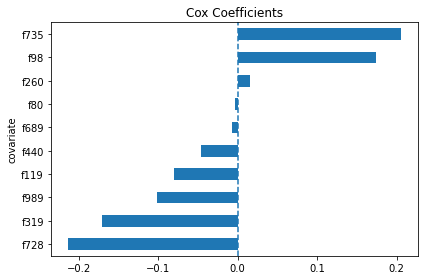

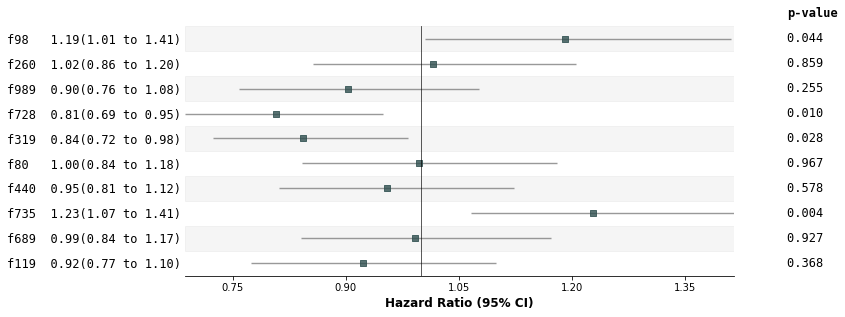

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.808 (95% CI 1.341 - 2.438), p = 0.000101
  G3 vs G1: HR = 2.757 (95% CI 2.079 - 3.657), p = 1.95e-12

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 1.808 (95% CI 1.341 - 2.438), p = 0.000101
  G3 vs G1: HR = 2.757 (95% CI 2.079 - 3.657), p = 1.95e-12


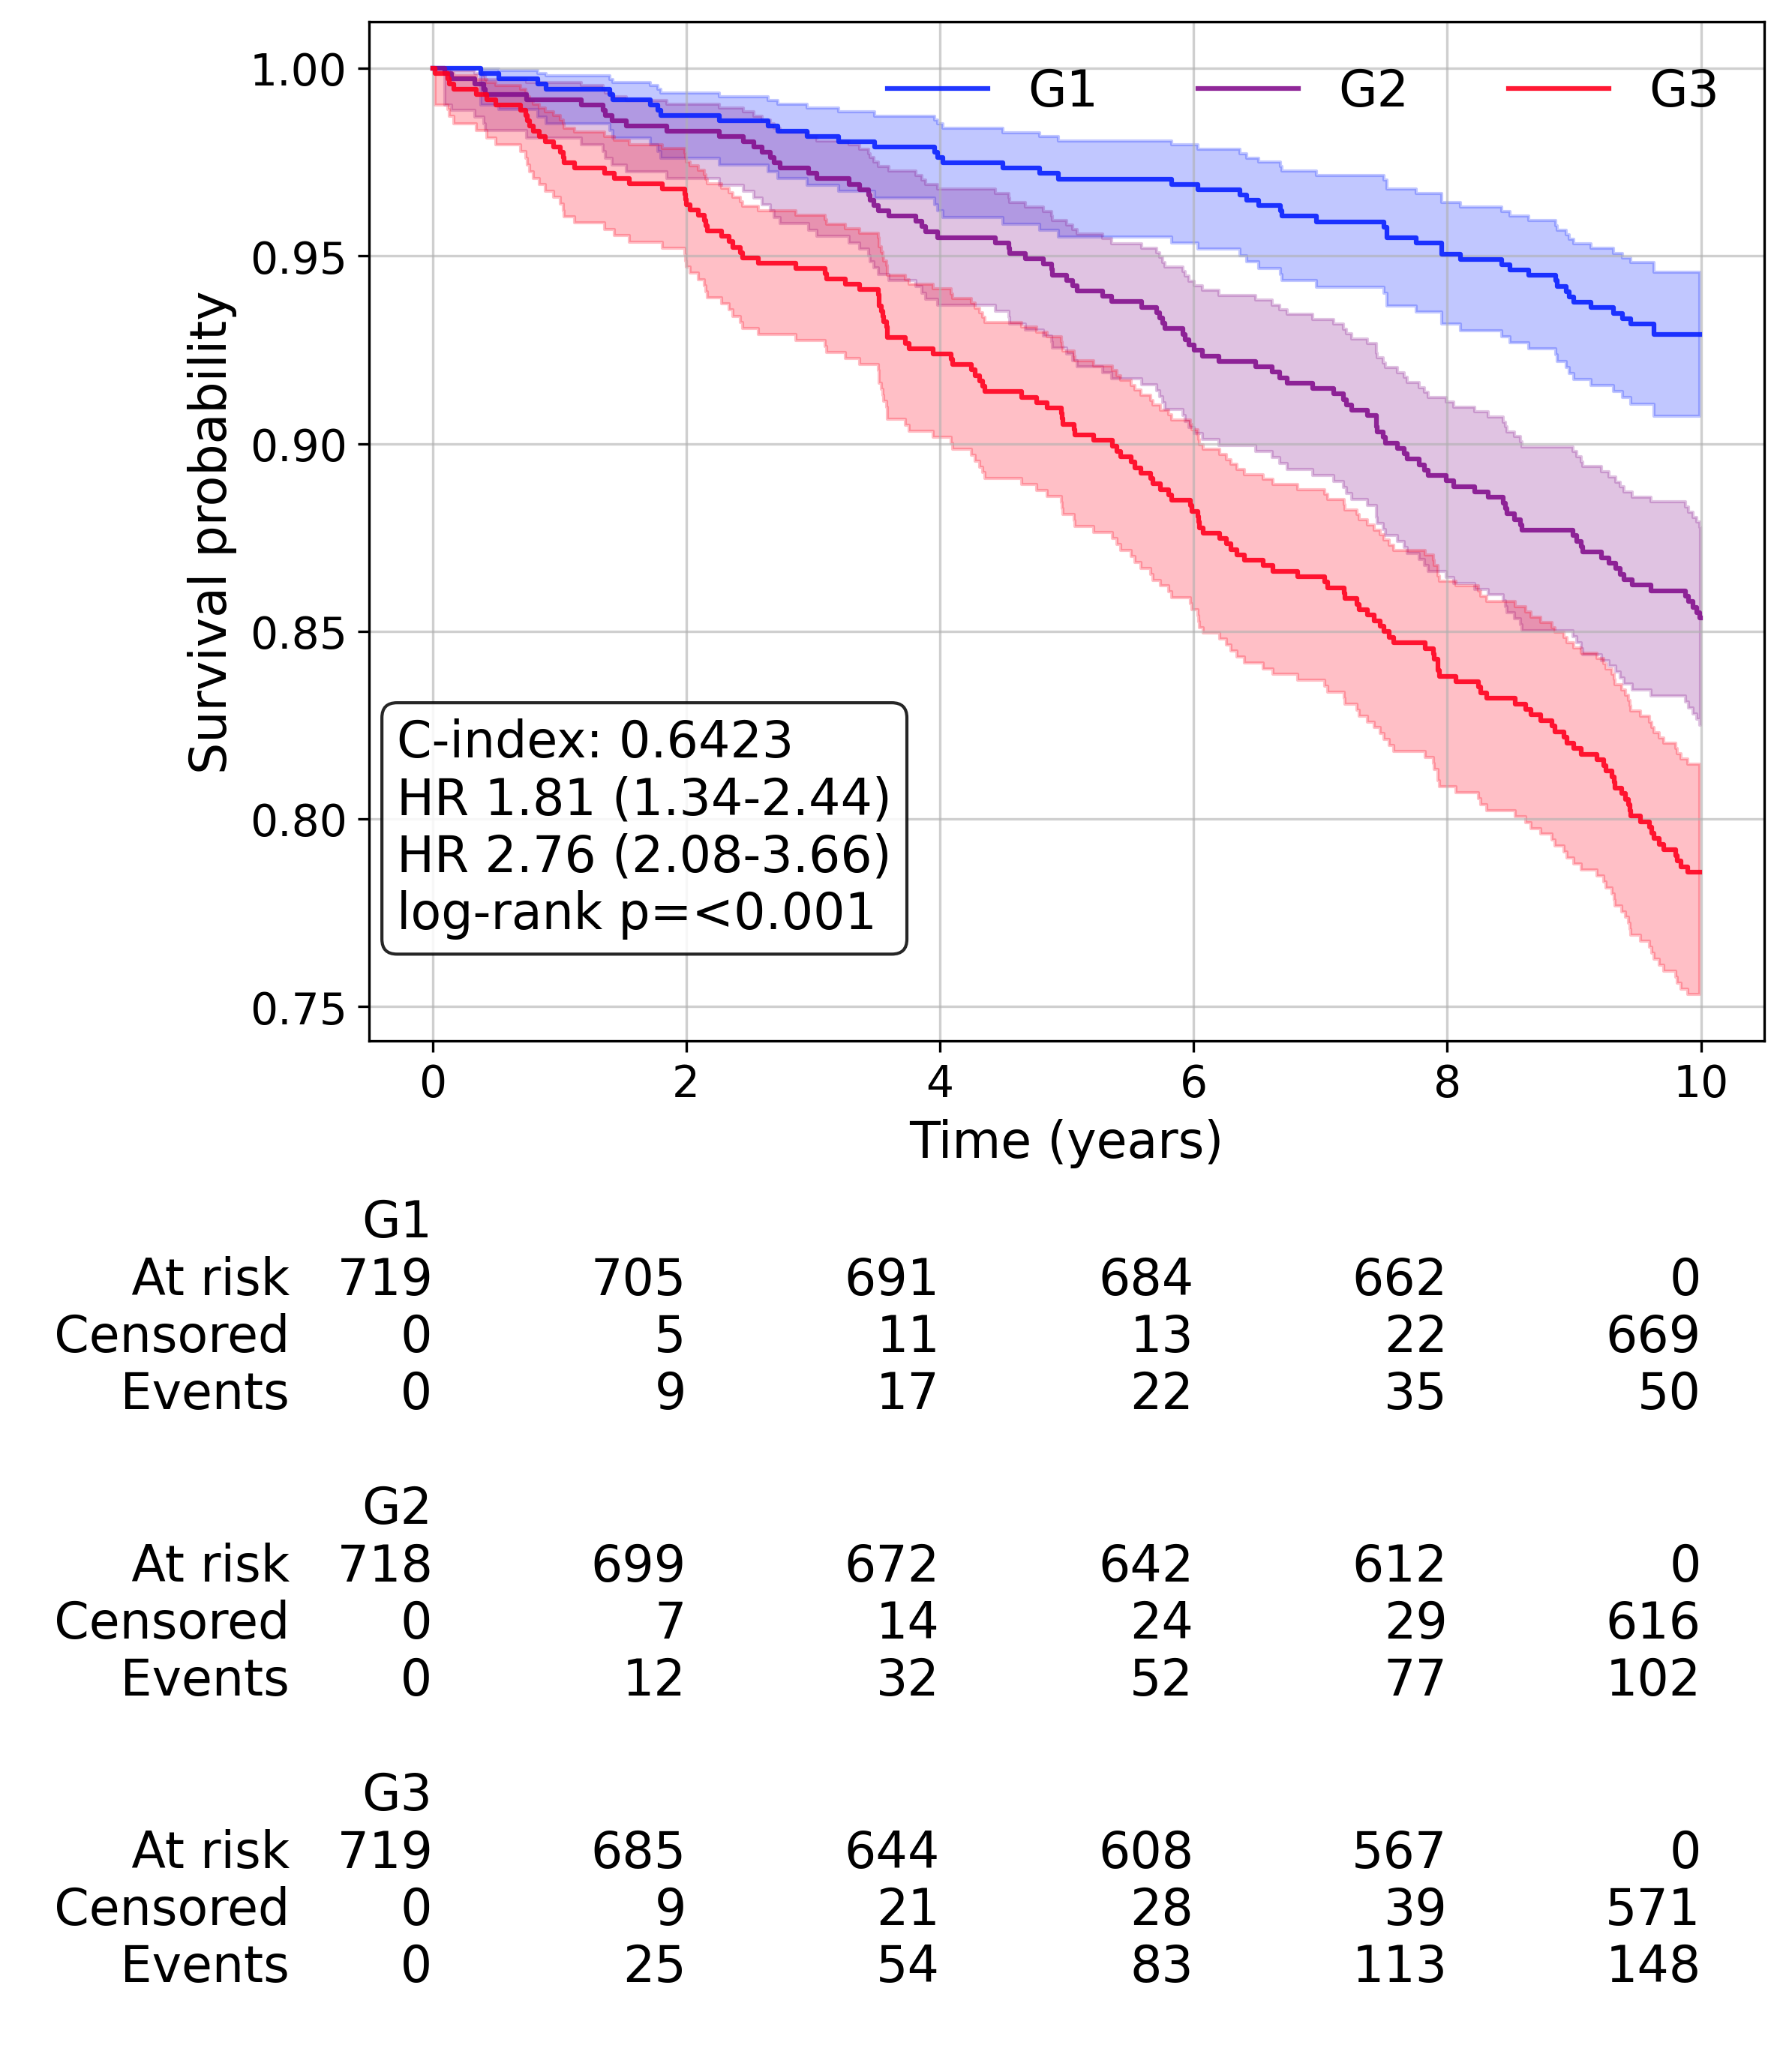

In [110]:


outputs = train_cox_model(train_df = cori_cohort_dict["D1"], 
    test_df = cori_cohort_dict["D1"],
    selected_features = cori_features,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## Train MMACE

 train shape: (14159, 1075)
 test shape: (14763, 1075)


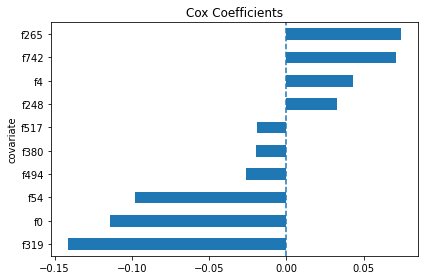

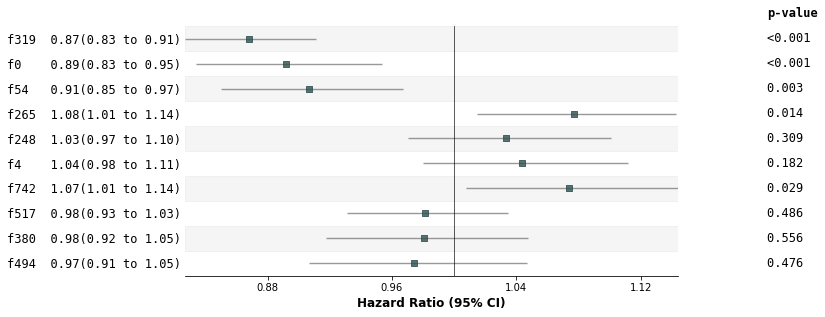

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.195 (95% CI 1.046 - 1.366), p = 0.00875
  G3 vs G1: HR = 2.046 (95% CI 1.811 - 2.310), p = 1e-30

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 1.039 (95% CI 0.901 - 1.197), p = 0.601
  G3 vs G1: HR = 1.633 (95% CI 1.436 - 1.858), p = 8.66e-14


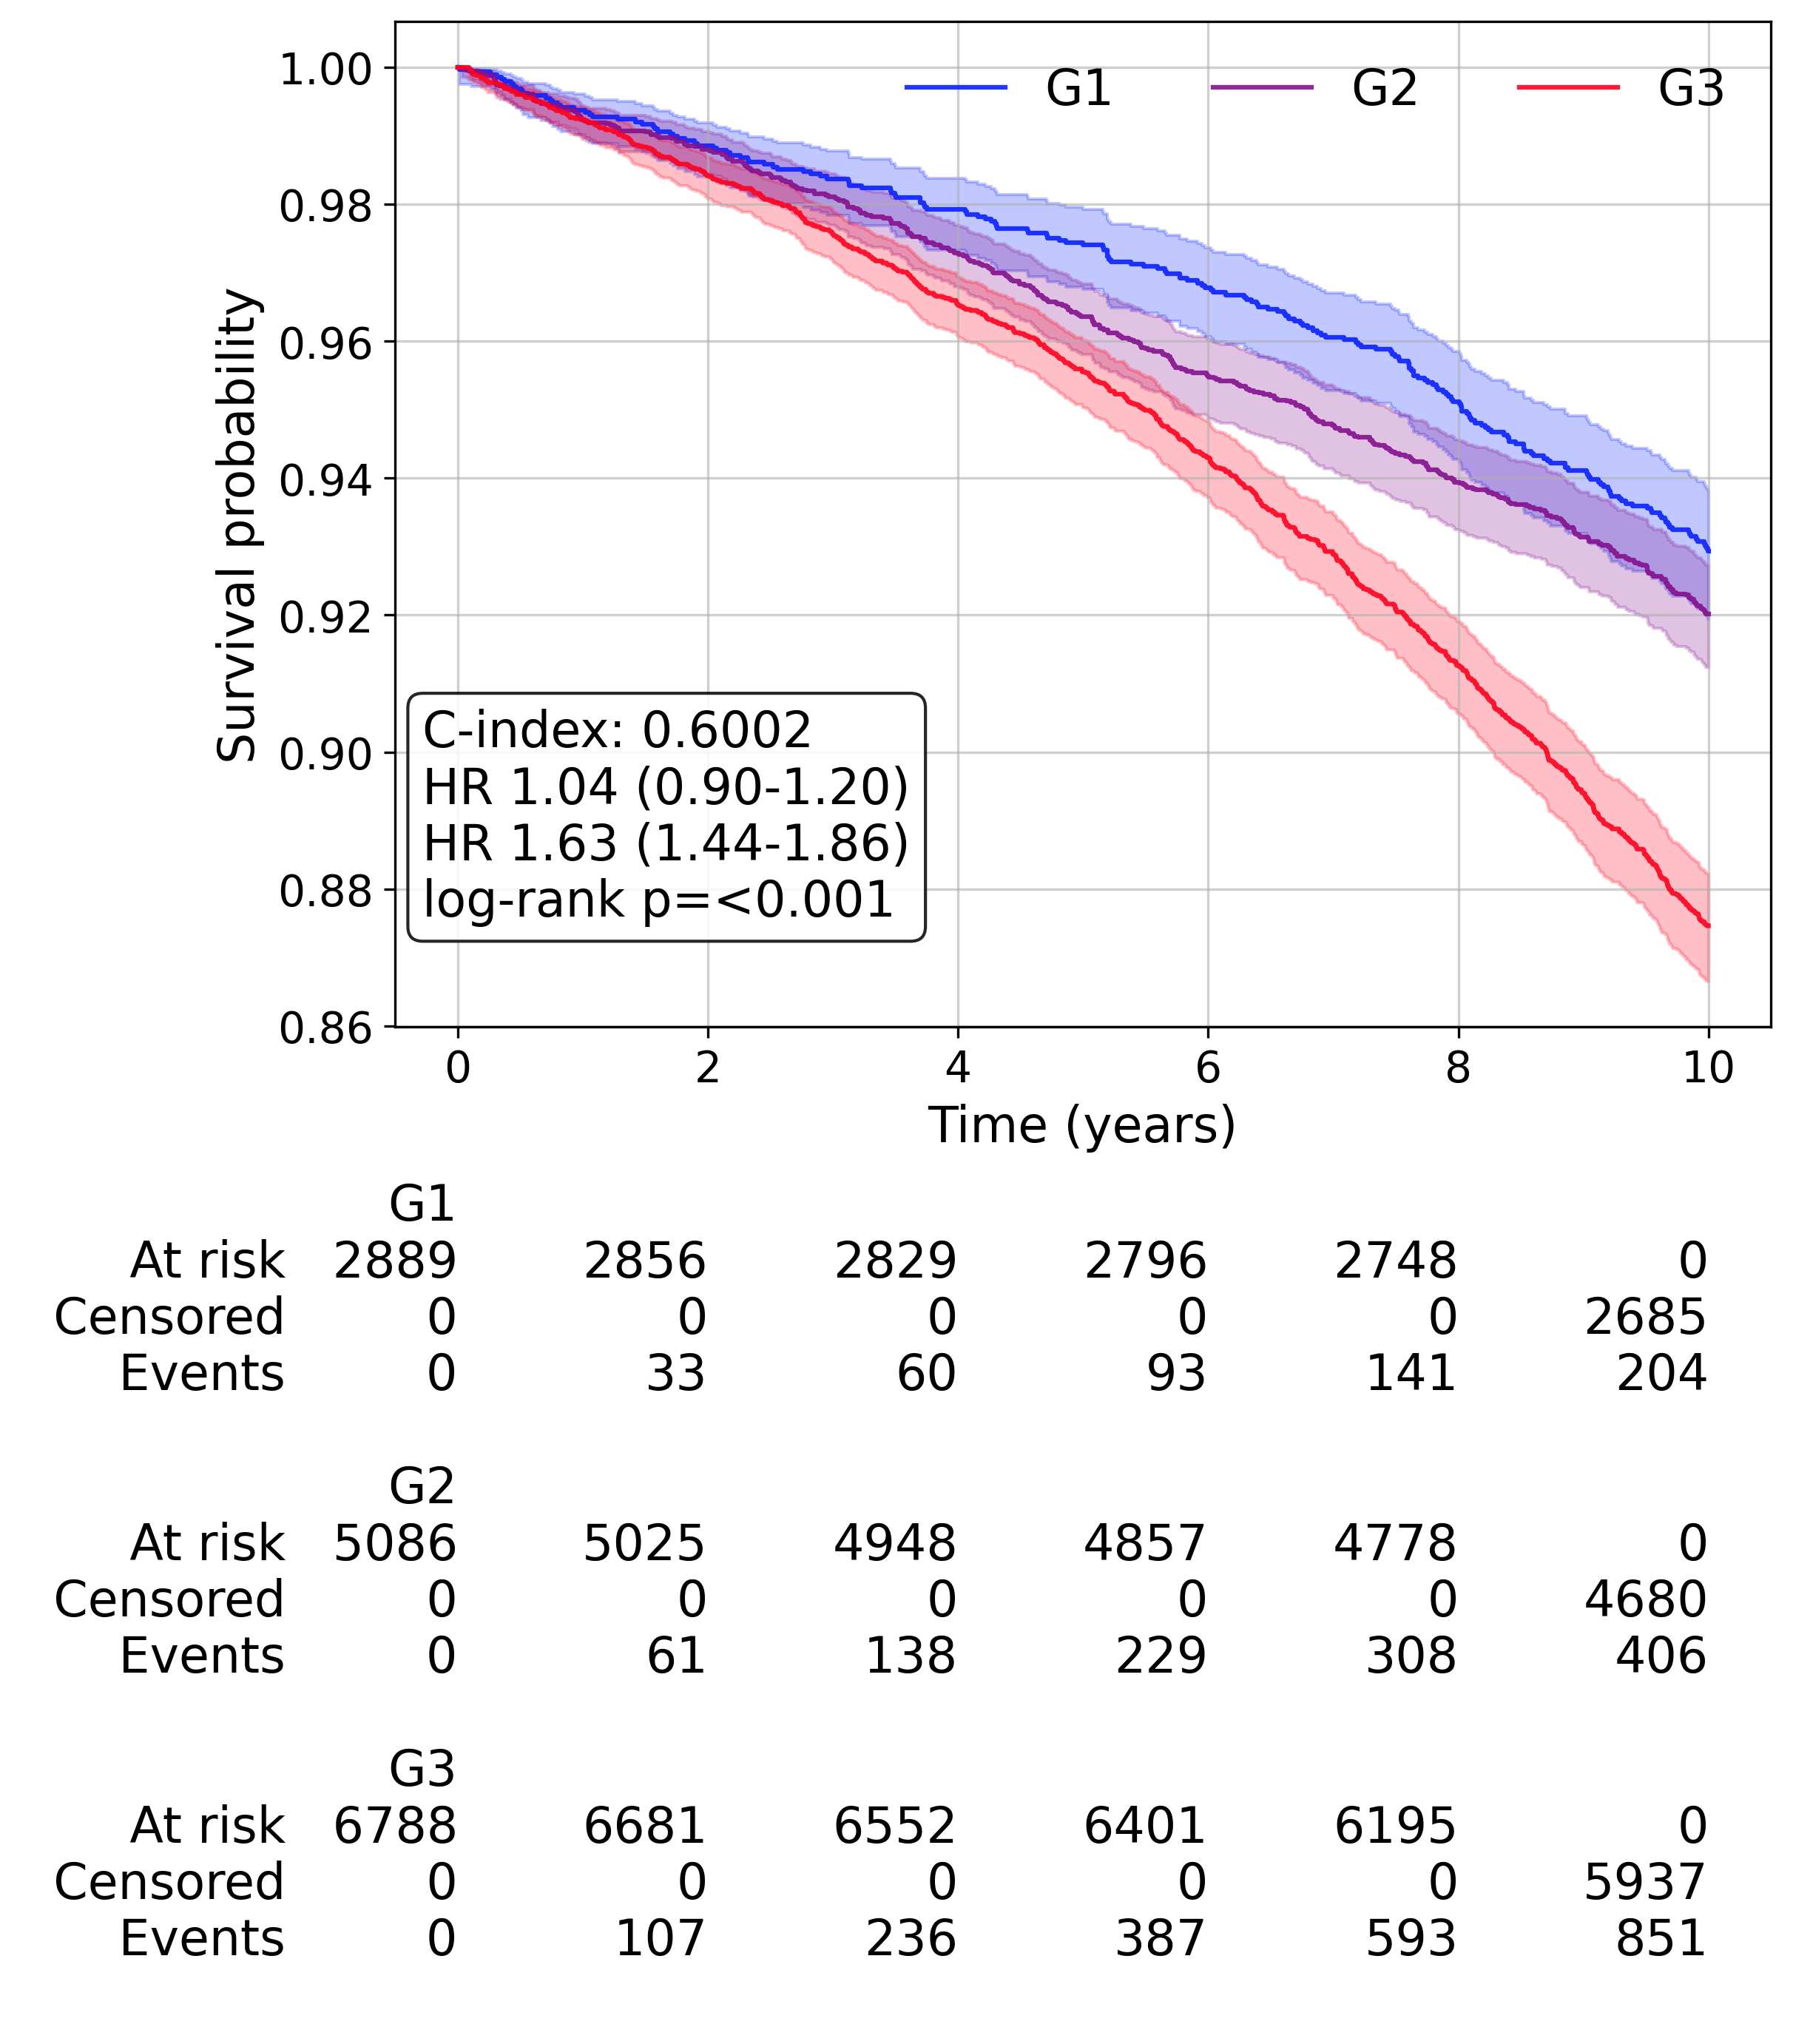

In [111]:


outputs = train_cox_model(train_df = mmace_cohort_dict["D3"],
    test_df = mmace_cohort_dict["D4"],
    selected_features = mmace_features, 
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## Test CORI on D3

 train shape: (2156, 1095)
 test shape: (14159, 1075)


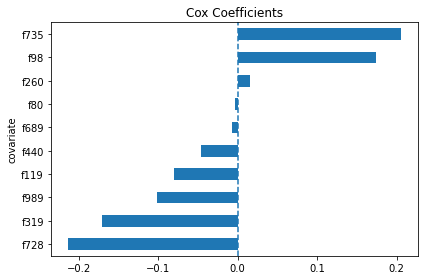

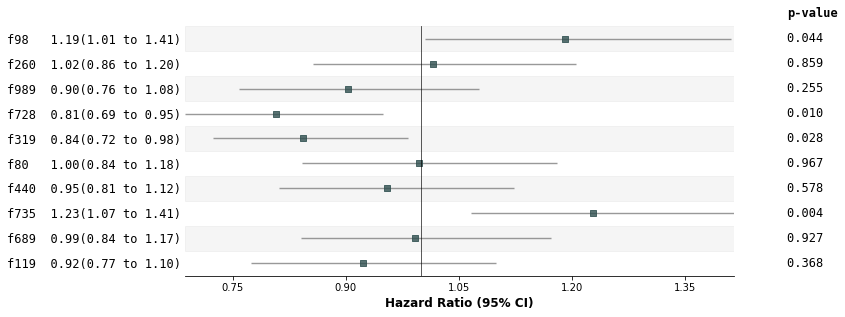

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.808 (95% CI 1.341 - 2.438), p = 0.000101
  G3 vs G1: HR = 2.757 (95% CI 2.079 - 3.657), p = 1.95e-12

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 0.492 (95% CI 0.392 - 0.617), p = 7.88e-10
  G3 vs G1: HR = 2.153 (95% CI 1.679 - 2.760), p = 1.53e-09


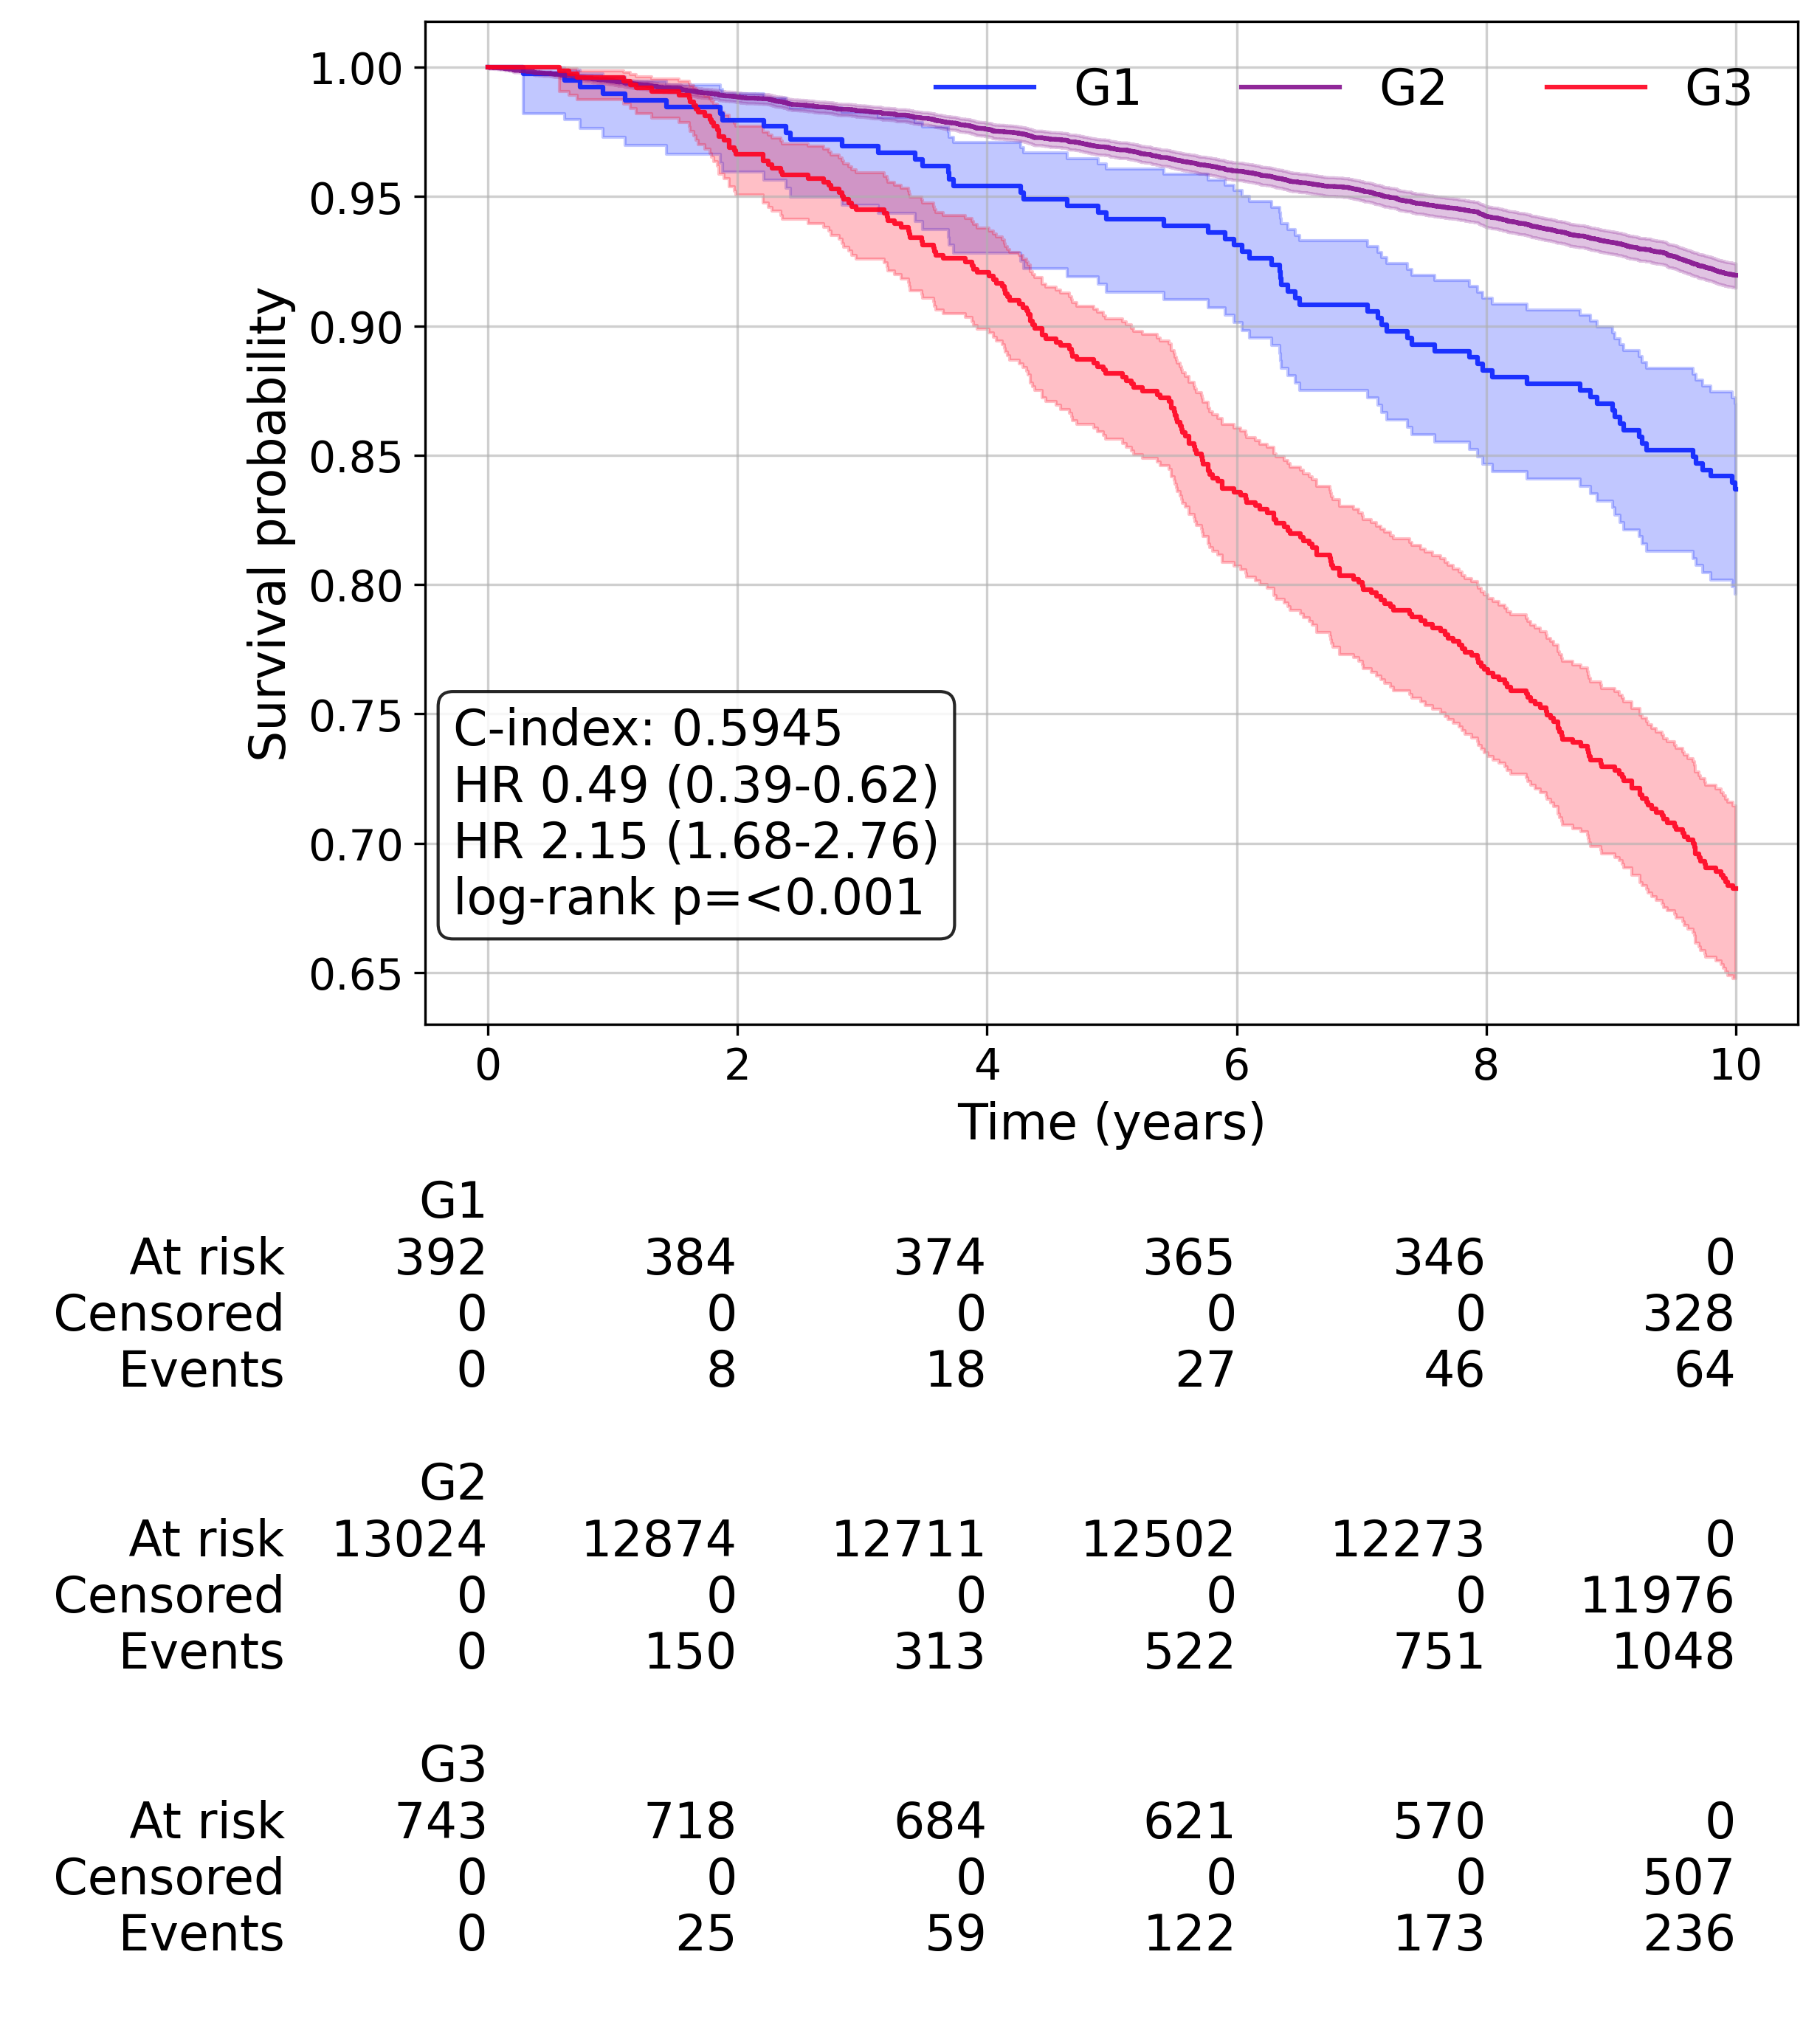

In [112]:
outputs = train_cox_model(train_df = cori_cohort_dict["D1"], 
    test_df = mmace_cohort_dict["D3"],
    selected_features = cori_features,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

## Test MMACE on D2

 train shape: (14159, 1075)
 test shape: (2435, 1095)


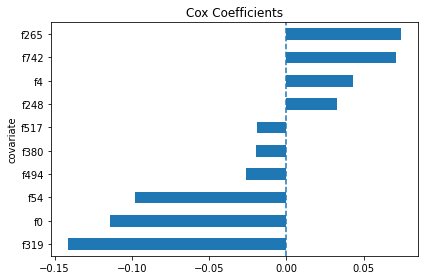

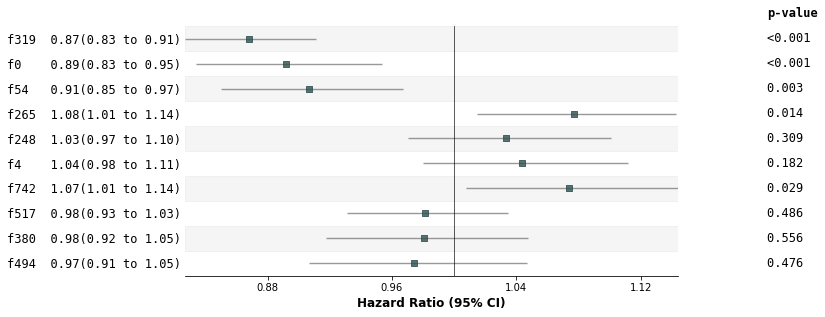

Percentiles not provided, using: [0.         0.33333333 0.66666667 1.        ]

Hazard Ratios (Train) -- each vs ref group
  G2 vs G1: HR = 1.195 (95% CI 1.046 - 1.366), p = 0.00875
  G3 vs G1: HR = 2.046 (95% CI 1.811 - 2.310), p = 1e-30

Hazard Ratios (Test)  -- each vs ref group
  G2 vs G1: HR = 0.238 (95% CI 0.026 - 2.198), p = 0.206
  G3 vs G1: HR = 2.343 (95% CI 1.013 - 5.420), p = 0.0465


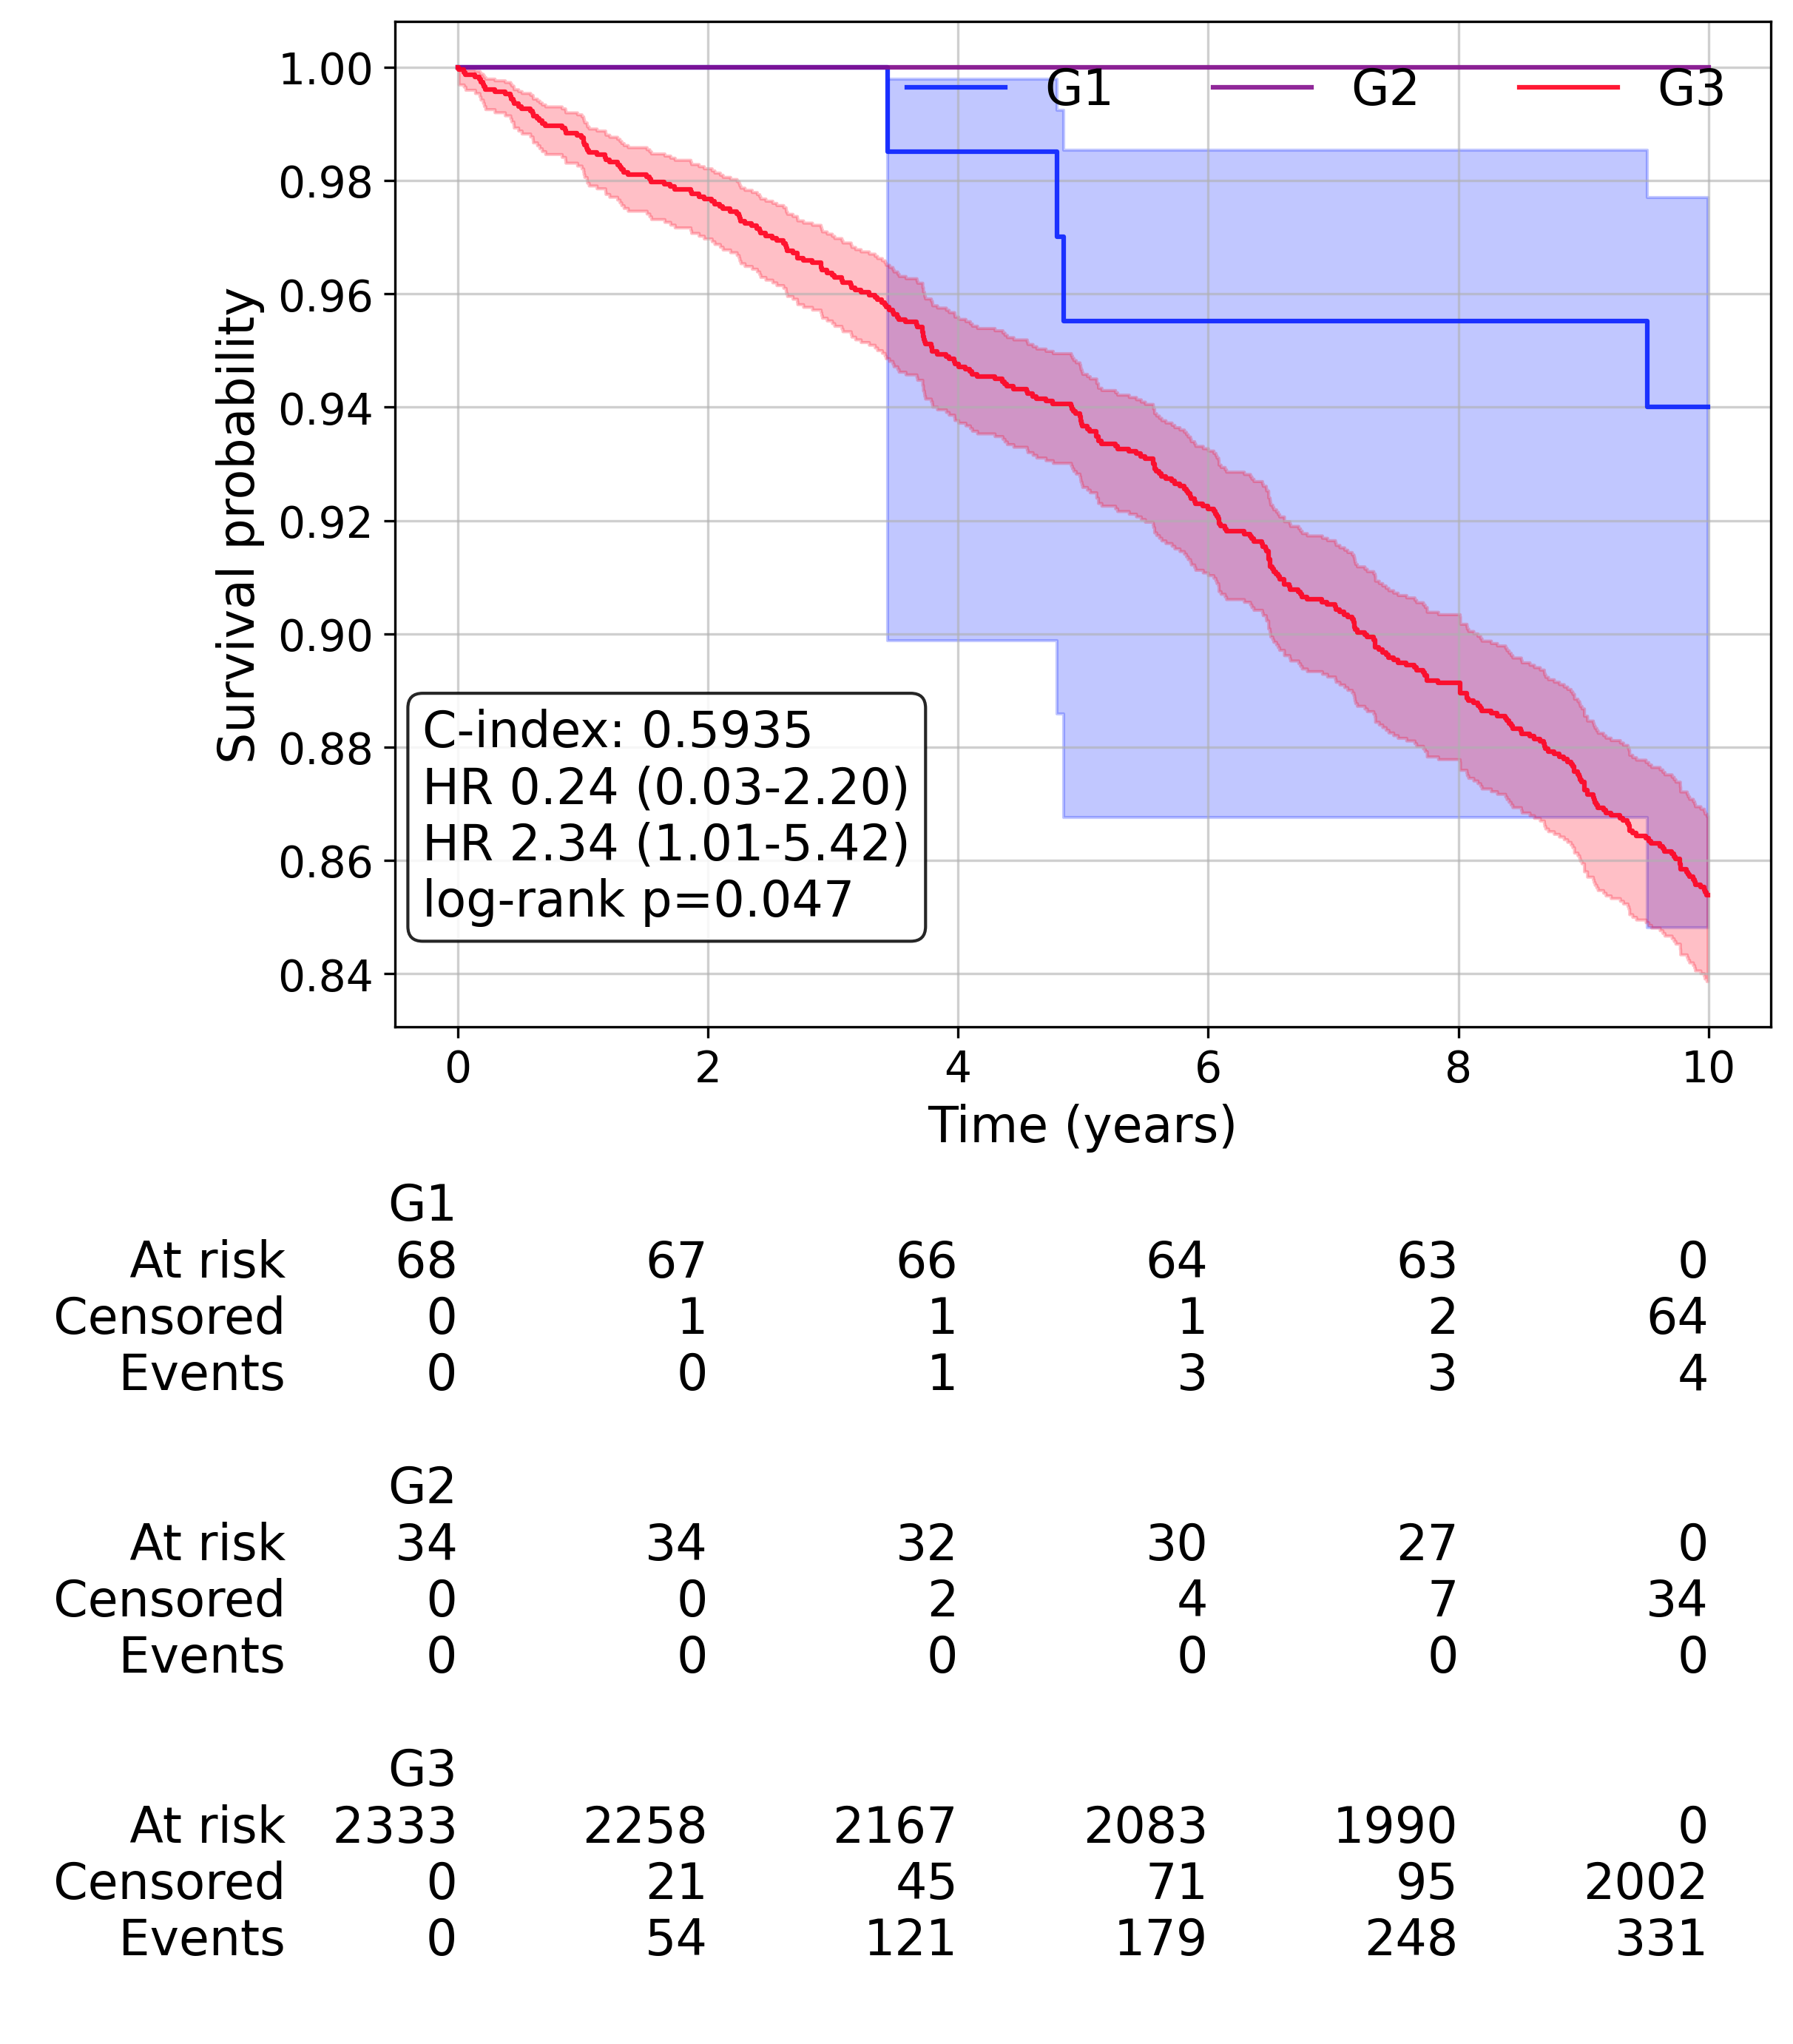

In [ ]:
outputs = train_cox_model(train_df = mmace_cohort_dict["D3"], 
    test_df = mmace_cohort_dict["D2"],
    selected_features =  mmace_features,
    time_col= time_col,
    event_col= event_col,
    organ_name="organ",
    save_dir=None,
    plot_km=True,
    plot_groups=[3],
    verbose=True)

In [115]:

CORI_K = 10
CORI_PENALIZER = 0.01

# Locked primary CORI used for manuscript validation.
cori_model = train_model(
    cori_cohort_dict["D1"],
    DEEP_FEATURES,
    name="CORI",
    n_features=CORI_K,
    penalizer=CORI_PENALIZER,
)

# # Controlled comparator: exact same effective complexity as locked CORI.
# mmace_equal_model = train_model(
#     meanpool["D3"],
#     DEEP_FEATURES,
#     name="MMACE_equal",
#     n_features=CORI_K,
#     penalizer=CORI_PENALIZER,
# )

MMACE_PRACTICAL_K = 100
MMACE_PRACTICAL_PENALIZER = 0.01

# Practical full-data sensitivity.
mmace_full_model = train_model(
    mmace_cohort_dict["D3"],
    DEEP_FEATURES,
    name="MMACE_full",
    n_features=MMACE_PRACTICAL_K,
    penalizer=MMACE_PRACTICAL_PENALIZER,
)



In [119]:
from src.models import LockedCoxModel, _design_from_training

def predict_risk(model: LockedCoxModel, df: pd.DataFrame, horizon: float = 10.0) -> np.ndarray:
    design = _design_from_training(df, model)
    # print(design)
    
    survival = model.cox_model.predict_survival_function(design, times=[horizon]).iloc[0].to_numpy()
    # predict risk directly from model.cox_model
    risk_score = model.cox_model.predict_partial_hazard(df[design.columns]).to_numpy()

    return risk_score # 1 - survival

# cori_cohort_dict = {
#     "D1": d1_coriPreProcess,
#     "D2": d2_coriPreProcess,
#     "D4": d4_coriPreProcess,
# }

# mmace_cohort_dict = {
#     "D3": d3_MMACEPreProcess,
#     "D4": d4_MMACEPreProcess,
#     "D2": d2_MMACEPreProcess,
# }
for cohort in ['D1', 'D2', 'D4']:
    # temp_mmace_riskScore = predict_risk(mmace_full_model, cori_cohort_dict[cohort])
    # temp_mmace_riskScore_zNorm = (temp_mmace_riskScore - np.mean(temp_mmace_riskScore)) / np.std(temp_mmace_riskScore)
    
    temp_cori_riskScore = predict_risk(cori_model, cori_cohort_dict[cohort])
    temp_cori_riskScore_zNorm = (temp_cori_riskScore - np.mean(temp_cori_riskScore)) / np.std(temp_cori_riskScore)
    
    cori_cohort_dict[cohort]['CORI_risk'] =  temp_cori_riskScore
    cori_cohort_dict[cohort]['CORI_z'] = temp_cori_riskScore_zNorm
    # cori_cohort_dict[cohort]['MMACE_risk'] = temp_mmace_riskScore
    # cori_cohort_dict[cohort]['MMACE_z'] = temp_mmace_riskScore_zNorm
    
cori_D1_median = np.median(cori_cohort_dict['D1']['CORI_z'])
cori_z_D1_median = np.median(cori_cohort_dict['D1']['CORI_z'])

# mmace_d3_median = np.median(cori_cohort_dict['D3']['MMACE_z'])
# mmace_z_d3_median = np.median(cori_cohort_dict['D3']['MMACE_z'])

for cohort in ['D1', 'D2','D4']:
    cori_cohort_dict[cohort]['CORI_high'] =  (cori_cohort_dict[cohort]['CORI_z'] > cori_z_D1_median).astype(int)
    # cori_cohort_dict[cohort]['MMACE_high'] = (cori_cohort_dict[cohort]['MMACE_z'] > mmace_z_d3_median).astype(int)
    

In [124]:


for cohort in ['D2', 'D4', 'D3']:
    temp_mmace_riskScore = predict_risk(mmace_full_model, mmace_cohort_dict[cohort])
    temp_mmace_riskScore_zNorm = (temp_mmace_riskScore - np.mean(temp_mmace_riskScore)) / np.std(temp_mmace_riskScore)
        
    mmace_cohort_dict[cohort]['MMACE_risk'] = temp_mmace_riskScore
    mmace_cohort_dict[cohort]['MMACE_z'] = temp_mmace_riskScore_zNorm
    
mmace_d3_median = np.median(mmace_cohort_dict['D3']['MMACE_z'])
mmace_z_d3_median = np.median(mmace_cohort_dict['D3']['MMACE_z'])

for cohort in ['D2','D4', 'D3']:
    # cori_cohort_dict[cohort]['CORI_high'] =  (cori_cohort_dict[cohort]['CORI_z'] > cori_z_D1_median).astype(int)
    mmace_cohort_dict[cohort]['MMACE_high'] = (mmace_cohort_dict[cohort]['MMACE_z'] > mmace_z_d3_median).astype(int)
    

In [125]:
# import seaborn as sns
# sns.displot(mmace_d2_riskscore, kde=True, stat="density", bins=10)
# sns.displot(mmace_d4_riskscore, kde=True, stat="density", bins=10)
# sns.displot(cori_d2_riskscore, kde=True, stat="density", bins=10)
# sns.displot(cori_d4_riskscore, kde=True, stat="density", bins=10)

# CORI value in D2

In [120]:

from tqdm import tqdm

from __future__ import annotations

import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from scipy.stats import chi2, pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

from src.data import truncate_followup


def get_c_index(df: pd.DataFrame, score_column: str, time_column: str = "time_years", event_column: str = "Y_mace") -> float:
    d = df[[time_column, event_column, score_column]].dropna()
    return float(concordance_index(d[time_column], -d[score_column], d[event_column]))


def bootstrap_c_index(
    df: pd.DataFrame,
    score_column: str,
    n_bootstraps: int = 1000,
    seed: int = 20260714,
) -> dict[str, float]:
    rng = np.random.default_rng(seed)
    estimates = []
    for _ in tqdm(range(n_bootstraps), desc="Bootstrapping"):
        sample = df.iloc[rng.integers(0, len(df), len(df))]
        if sample["Y_mace"].nunique() < 2:
            continue
        estimates.append(get_c_index(sample, score_column))
    estimates = np.asarray(estimates)
    return {
        "C_index": get_c_index(df, score_column),
        "C_low": float(np.quantile(estimates, 0.025)),
        "C_high": float(np.quantile(estimates, 0.975)),
        "successful_bootstraps": int(len(estimates)),
    }

def performance_row(df: pd.DataFrame, cohort: str, score_column: str, high_column: str, n_bootstraps: int = 1000) -> dict:
    c = bootstrap_c_index(df, score_column, n_bootstraps=n_bootstraps)
    hr = high_low_hr(df, high_column)
    return {
        "cohort": cohort,
        "N": len(df),
        "events": int(df["Y_mace"].sum()),
        **c,
        **hr,
    }

Bootstrapping: 100%|██████████| 100/100 [00:00<00:00, 193.22it/s]


,cohort,N,events,C_index,C_low,C_high,successful_bootstraps,HR,HR_low,HR_high,p
0,D1 development,2156,300,0.642364,0.618203,0.674234,100,2.100006,1.652768,2.668267,1.263228e-09
1,D2 held-out,2435,335,0.633794,0.608942,0.666602,100,2.164122,1.723708,2.717063,2.930883e-11


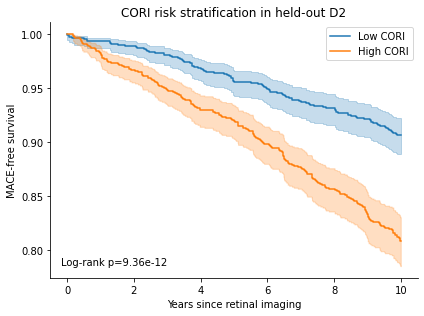

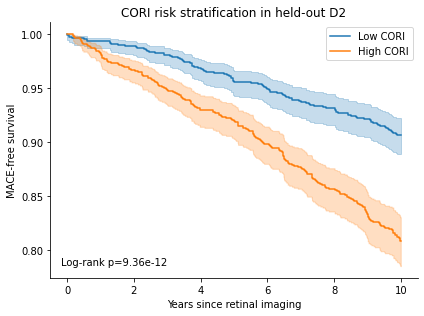

In [121]:
time_column = "time_years"
event_column = "Y_mace"

temp_train_df = cori_cohort_dict["D1"][[time_column, event_column, "CORI_z", "CORI_high"]]
temp_test_df = cori_cohort_dict["D2"][[time_column, event_column, "CORI_z", "CORI_high"]]

primary_CORI_performance = pd.DataFrame([
    performance_row(temp_train_df, "D1 development", "CORI_z", "CORI_high", 100),
    performance_row(temp_test_df, "D2 held-out", "CORI_z", "CORI_high", 100),
])
display(primary_CORI_performance)
# save_table(primary_CORI_performance, "Table_02_primary_CORI_performance")

# horizons = horizon_table(temp_test_df, "CORI_z", "CORI_high", horizons=(3, 5, 10))
# # save_table(horizons, "Table_03_CORI_horizon_performance")

km_plot(
    cori_cohort_dict["D2"], "CORI_high", {0: "Low CORI", 1: "High CORI"},
    "CORI risk stratification in held-out D2", FIGURE_DIR / "Figure_02A_CORI_D2_KM",
)

## MAMCE on D4

Bootstrapping: 100%|██████████| 100/100 [00:03<00:00, 31.75it/s]


,cohort,N,events,C_index,C_low,C_high,successful_bootstraps,HR,HR_low,HR_high,p
0,D3 development,14159,1348,0.633591,0.619589,0.648350,100,2.028873,1.812277,2.271357,1.126901e-34
1,D4 held-out,14763,1461,0.623067,0.608124,0.636783,100,2.744522,2.443609,3.082490,4.193614e-65


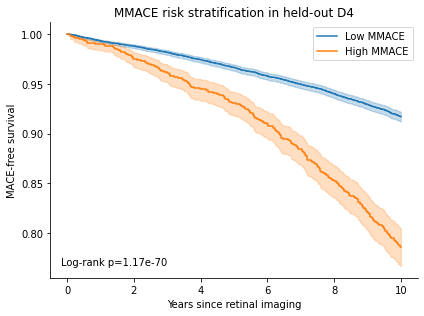

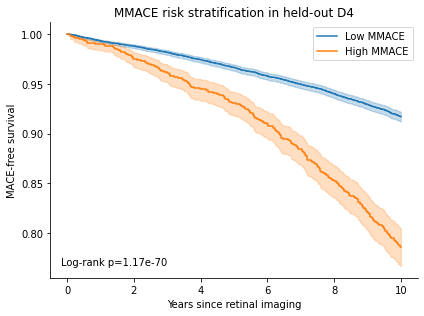

In [126]:
time_column = "time_years"
event_column = "Y_mace"

temp_train_df = mmace_cohort_dict["D3"][[time_column, event_column, "MMACE_z", "MMACE_high"]]
temp_test_df = mmace_cohort_dict["D4"][[time_column, event_column, "MMACE_z", "MMACE_high"]]

primary_MMACE_performance = pd.DataFrame([
    performance_row(temp_train_df, "D3 development", "MMACE_z", "MMACE_high", 100),
    performance_row(temp_test_df, "D4 held-out", "MMACE_z", "MMACE_high", 100),
])
display(primary_MMACE_performance)
# save_table(primary_MMACE_performance, "Table_02_primary_MMACE_performance")

# horizons = horizon_table(temp_test_df, "CORI_z", "CORI_high", horizons=(3, 5, 10))
# # save_table(horizons, "Table_03_CORI_horizon_performance")

# horizons = horizon_table(meanpool["D4"], "MMACE_z", "MMACE_high", horizons=(3, 5, 10))
# # save_table(horizons, "Table_03_CORI_horizon_performance")

km_plot(
    temp_test_df, "MMACE_high", {0: "Low MMACE", 1: "High MMACE"},
    "MMACE risk stratification in held-out D4", FIGURE_DIR / "Figure_02A_MMACE_D4_KM",
)


## Cross testing: Cori on D4, MAMCE on D2

In [127]:
time_column = "time_years"
event_column = "Y_mace"

temp_test_df1 = cori_cohort_dict["D4"][[time_column, event_column, "CORI_z", "CORI_high"]]
temp_test_df2 = mmace_cohort_dict["D2"][[time_column, event_column, "MMACE_z", "MMACE_high"]]


primary_crosstesting_performance = pd.DataFrame([
    performance_row(temp_test_df1, "D4 development", "CORI_z", "CORI_high", 100),
    performance_row(temp_test_df2, "D2 held-out", "MMACE_z", "MMACE_high", 100),
])

display(primary_crosstesting_performance)

# save_table(primary_MMACE_performance, "Table_02_primary_MMACE_performance")

# horizons = horizon_table(temp_test_df, "CORI_z", "CORI_high", horizons=(3, 5, 10))
# # save_table(horizons, "Table_03_CORI_horizon_performance")

# horizons = horizon_table(meanpool["D4"], "MMACE_z", "MMACE_high", horizons=(3, 5, 10))
# # save_table(horizons, "Table_03_CORI_horizon_performance")

Bootstrapping: 100%|██████████| 100/100 [00:00<00:00, 179.63it/s]


,cohort,N,events,C_index,C_low,C_high,successful_bootstraps,HR,HR_low,HR_high,p
0,D4 development,14763,1461,0.593944,0.579856,0.608595,100,1.252362,1.071054,1.464362,4.798554e-03
1,D2 held-out,2435,335,0.620605,0.592279,0.655341,100,2.146395,1.699643,2.710577,1.411386e-10


# Combined model: Clinical, CORI, and combined models

In [ ]:
clinical_model = train_model(
    meanpool["D1"], CLINICAL_VARIABLES,
    name="Clinical", n_features=len(CLINICAL_VARIABLES), penalizer=0.01,
)
combined_features = [*CLINICAL_VARIABLES, "CORI_z"]
combined_model = train_model(
    meanpool["D1"], combined_features,
    name="Clinical_CORI", n_features=len(combined_features), penalizer=0.01,
)

for cohort in ["D1", "D2"]:
    meanpool[cohort] = score_model(clinical_model, meanpool[cohort])
    meanpool[cohort] = score_model(combined_model, meanpool[cohort])
    meanpool[cohort]["Clinical_risk_10y"] = predict_risk(clinical_model, meanpool[cohort], 10)
    meanpool[cohort]["Clinical_CORI_risk_10y"] = predict_risk(combined_model, meanpool[cohort], 10)

clinical_comparison = pd.DataFrame([
    {"model": "Clinical", "D1_C": c_index(meanpool["D1"], "Clinical_z"), "D2_C": c_index(meanpool["D2"], "Clinical_z")},
    {"model": "CORI", "D1_C": c_index(meanpool["D1"], "CORI_z"), "D2_C": c_index(meanpool["D2"], "CORI_z")},
    {"model": "Clinical + CORI", "D1_C": c_index(meanpool["D1"], "Clinical_CORI_z"), "D2_C": c_index(meanpool["D2"], "Clinical_CORI_z")},
])
save_table(clinical_comparison, "Table_04_clinical_CORI_combined_performance")

adjusted_cori, adjusted_cori_model = adjusted_cox(
    meanpool["D2"], "CORI_z", PRIMARY_ADJUSTMENT
)
save_table(adjusted_cori, "Table_05_D2_multivariable_CORI_association")

clinical_thresholds = score_thresholds(meanpool["D1"]["Clinical_risk_10y"])
for cohort in ["D1", "D2"]:
    meanpool[cohort] = add_groups(meanpool[cohort], "Clinical_risk_10y", clinical_thresholds, "Clinical_risk")

counts, event_rates, predicted = reclassification_tables(
    meanpool["D2"], "Clinical_risk_tertile", "CORI_tertile", value_column="Clinical_CORI_risk_10y"
)
counts.to_csv(TABLE_DIR / "Table_08A_clinical_to_CORI_counts.csv")
event_rates.to_csv(TABLE_DIR / "Table_08B_clinical_to_CORI_event_rates.csv")
predicted.to_csv(TABLE_DIR / "Table_08C_clinical_to_CORI_mean_predicted_risk.csv")
reclassification_heatmap(event_rates, "Observed MACE within clinical and CORI strata", FIGURE_DIR / "Figure_02B_clinical_CORI_reclassification")

calibration, _ = calibration_plot(
    meanpool["D2"], "Clinical_CORI_risk_10y", "Y_mace",
    "Clinical + CORI calibration in D2", FIGURE_DIR / "Figure_S_calibration_clinical_CORI",
)
save_table(calibration, "Table_S_clinical_CORI_calibration_deciles")

## 10. CORI versus controlled, tuned, practical, and matched MMACE

In [ ]:
rows = []
score_models = [
    ("CORI locked", "CORI_z"),
    ("CORI tuned sensitivity", "CORI_tuned_z"),
    ("MMACE equal complexity", "MMACE_equal_z"),
    ("MMACE independently tuned", "MMACE_tuned_z"),
    ("MMACE practical", "MMACE_full_z"),
    ("MMACE matched ensemble sensitivity", "MMACE_matched_ensemble_z"),
]
for cohort in ["D1", "D2", "D3", "D4"]:
    for model_label, score_column in score_models:
        rows.append(
            {
                "cohort": cohort,
                "model": model_label,
                "C_index": c_index(meanpool[cohort], score_column),
            }
        )
for cohort in ["D2", "D4"]:
    rows.append(
        {
            "cohort": cohort,
            "model": "MMACE crude matched ensemble sensitivity",
            "C_index": c_index(
                meanpool[cohort],
                "MMACE_crude_matched_ensemble_z",
            ),
        }
    )

cross_domain = pd.DataFrame(rows)
display(cross_domain)
save_table(cross_domain, "Table_09_cross_domain_CORI_MMACE")

paired_rows = []
for label, score_column in [
    ("CORI minus equal-complexity MMACE", "MMACE_equal_z"),
    ("CORI minus independently tuned MMACE", "MMACE_tuned_z"),
    ("CORI minus practical MMACE", "MMACE_full_z"),
    ("CORI minus matched-MMACE ensemble sensitivity", "MMACE_matched_ensemble_z"),
]:
    paired_rows.append(
        {
            "comparison": label,
            **paired_delta_c(
                meanpool["D2"],
                "CORI_z",
                score_column,
                BOOTSTRAPS,
                SEED,
            ),
        }
    )
save_table(pd.DataFrame(paired_rows), "Table_09C_paired_D2_delta_C")

# Primary participant-level reclassification uses deterministic equal-complexity MMACE.
counts, event_rates, _ = reclassification_tables(
    meanpool["D2"],
    "MMACE_equal_tertile",
    "CORI_tertile",
)
counts.to_csv(TABLE_DIR / "Table_10A_equal_MMACE_to_CORI_counts.csv")
event_rates.to_csv(TABLE_DIR / "Table_10B_equal_MMACE_to_CORI_event_rates.csv")



nri_rows = [
    {
        "comparison": "Equal-complexity MMACE to CORI",
        **categorical_nri(
            meanpool["D2"],
            "MMACE_equal_tertile",
            "CORI_tertile",
        ),
    },
    {
        "comparison": "Practical MMACE to CORI",
        **categorical_nri(
            meanpool["D2"],
            "MMACE_full_tertile",
            "CORI_tertile",
        ),
    },
]
save_table(pd.DataFrame(nri_rows), "Table_10C_MMACE_to_CORI_category_NRI")

In [ ]:


reclassification_heatmap(
    event_rates,
    "Observed MACE within equal-complexity MMACE and CORI strata",
    FIGURE_DIR / "Figure_03A_equal_MMACE_CORI_reclassification",
)


In [ ]:
# ============================================================
# D2 cancer-domain reclassification heatmap
# D1-defined tertiles for both locked CORI and full MMACE
# Matplotlib only
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CORI_SCORE = "CORI_z"
MMACE_SCORE = "MMACE_full_z"

required = {
    CORI_SCORE,
    MMACE_SCORE,
    "Y_mace",
}

for cohort in ["D1", "D2"]:
    missing = required - set(meanpool[cohort].columns)

    if missing:
        raise KeyError(
            f"{cohort} is missing: {sorted(missing)}"
        )


# ------------------------------------------------------------
# Derive both tertile thresholds from D1 cancer development
# ------------------------------------------------------------

cori_d1_thresholds = score_thresholds(
    pd.to_numeric(
        meanpool["D1"][CORI_SCORE],
        errors="coerce",
    ).dropna()
)

mmace_d1_thresholds = score_thresholds(
    pd.to_numeric(
        meanpool["D1"][MMACE_SCORE],
        errors="coerce",
    ).dropna()
)

threshold_table = pd.DataFrame(
    [
        {
            "model": "Locked CORI",
            "reference_cohort": "D1 cancer development",
            "score_column": CORI_SCORE,
            **cori_d1_thresholds,
        },
        {
            "model": "Full MMACE",
            "reference_cohort": "D1 cancer development",
            "score_column": MMACE_SCORE,
            **mmace_d1_thresholds,
        },
    ]
)

display(threshold_table)

save_table(
    threshold_table,
    "Table_10A_D1_referenced_CORI_full_MMACE_thresholds",
)


# ------------------------------------------------------------
# Apply the D1 thresholds unchanged to D2
# ------------------------------------------------------------

D2 = meanpool["D2"].copy()

D2 = add_groups(
    D2,
    CORI_SCORE,
    cori_d1_thresholds,
    "CORI_D1ref",
)

D2 = add_groups(
    D2,
    MMACE_SCORE,
    mmace_d1_thresholds,
    "MMACE_full_D1ref",
)

CORI_GROUP = "CORI_D1ref_tertile"
MMACE_GROUP = "MMACE_full_D1ref_tertile"

group_order = [
    "Low",
    "Middle",
    "High",
]

plot_data = (
    D2[
        [
            "Y_mace",
            CORI_GROUP,
            MMACE_GROUP,
        ]
    ]
    .dropna()
    .copy()
)

plot_data["Y_mace"] = pd.to_numeric(
    plot_data["Y_mace"],
    errors="raise",
).astype(int)


# ------------------------------------------------------------
# Construct 3 × 3 tables
# ------------------------------------------------------------

counts = pd.crosstab(
    plot_data[MMACE_GROUP],
    plot_data[CORI_GROUP],
).reindex(
    index=group_order,
    columns=group_order,
    fill_value=0,
)

event_counts = pd.crosstab(
    plot_data[MMACE_GROUP],
    plot_data[CORI_GROUP],
    values=plot_data["Y_mace"],
    aggfunc="sum",
).reindex(
    index=group_order,
    columns=group_order,
).fillna(0)

event_rates = pd.crosstab(
    plot_data[MMACE_GROUP],
    plot_data[CORI_GROUP],
    values=plot_data["Y_mace"],
    aggfunc="mean",
).reindex(
    index=group_order,
    columns=group_order,
)

event_rate_percent = 100 * event_rates


# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------

counts.to_csv(
    TABLE_DIR
    / "Table_10B_D1ref_full_MMACE_CORI_counts.csv"
)

event_counts.to_csv(
    TABLE_DIR
    / "Table_10C_D1ref_full_MMACE_CORI_event_counts.csv"
)

event_rates.to_csv(
    TABLE_DIR
    / "Table_10D_D1ref_full_MMACE_CORI_event_rates.csv"
)


# ------------------------------------------------------------
# Plot with Matplotlib
# ------------------------------------------------------------

values = event_rate_percent.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(7.2, 5.9))

image = ax.imshow(
    values,
    cmap="Blues",
    origin="lower",
    aspect="equal",
    interpolation="nearest",
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.83,
    pad=0.03,
)

colorbar.set_label(
    "Observed 10-year MACE rate (%)",
    fontsize=11,
)

ax.set_xticks(np.arange(3))
ax.set_yticks(np.arange(3))

ax.set_xticklabels(
    group_order,
    fontsize=10,
)

ax.set_yticklabels(
    group_order,
    fontsize=10,
)

ax.set_xlabel(
    "Locked CORI risk tertile",
    fontsize=12,
    labelpad=9,
)

ax.set_ylabel(
    "Full MMACE risk tertile",
    fontsize=12,
    labelpad=9,
)

ax.set_title(
    "Observed MACE across full MMACE and CORI risk strata\n"
    "D1-defined thresholds applied to held-out D2",
    fontsize=13,
    pad=13,
)


# Cell borders
ax.set_xticks(
    np.arange(-0.5, 3, 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, 3, 1),
    minor=True,
)

ax.grid(
    which="minor",
    linewidth=1.5,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)


# ------------------------------------------------------------
# Cell annotations
# ------------------------------------------------------------

finite_values = values[np.isfinite(values)]

if finite_values.size:
    threshold = (
        finite_values.min()
        + finite_values.max()
    ) / 2
else:
    threshold = 0

for row_index, mmace_group in enumerate(group_order):
    for column_index, cori_group in enumerate(group_order):

        n_total = int(
            counts.loc[mmace_group, cori_group]
        )

        n_events = int(
            event_counts.loc[
                mmace_group,
                cori_group,
            ]
        )

        rate = event_rate_percent.loc[
            mmace_group,
            cori_group,
        ]

        if n_total == 0 or pd.isna(rate):
            label = "No participants"
            text_color = "black"
        else:
            label = (
                f"{rate:.1f}%\n"
                f"{n_events}/{n_total} events"
            )

            text_color = (
                "white"
                if rate > threshold
                else "black"
            )

        ax.text(
            column_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=10,
            color=text_color,
        )


# Risk direction
ax.text(
    0.0,
    -0.13,
    "Lower CORI risk",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

ax.text(
    1.0,
    -0.13,
    "Higher CORI risk",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
)

ax.text(
    -0.14,
    0.0,
    "Lower full MMACE risk",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    rotation=90,
    fontsize=9,
)

ax.text(
    -0.14,
    1.0,
    "Higher full MMACE risk",
    transform=ax.transAxes,
    ha="right",
    va="top",
    rotation=90,
    fontsize=9,
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "Figure_03A_D1ref_full_MMACE_CORI_reclassification.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_DIR
    / "Figure_03A_D1ref_full_MMACE_CORI_reclassification.pdf",
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Audit
# ------------------------------------------------------------

print("\nD2 group sizes:")

display(
    pd.DataFrame(
        {
            "CORI_D1ref": (
                D2[CORI_GROUP]
                .value_counts()
                .reindex(group_order)
            ),
            "MMACE_full_D1ref": (
                D2[MMACE_GROUP]
                .value_counts()
                .reindex(group_order)
            ),
        }
    )
)

display(counts)
display(event_rate_percent.round(1))

In [ ]:
# ============================================================
# Categorical NRI:
# Full MMACE reference -> locked CORI
# D1-defined tertiles applied to held-out D2
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import norm

OLD_GROUP = "MMACE_full_D1ref_tertile"
NEW_GROUP = "CORI_D1ref_tertile"

group_numeric = {
    "Low": 1,
    "Middle": 2,
    "Mid": 2,
    "High": 3,
    "T1": 1,
    "T2": 2,
    "T3": 3,
}

nri_data = (
    D2[
        [
            "Y_mace",
            OLD_GROUP,
            NEW_GROUP,
        ]
    ]
    .dropna()
    .copy()
)

nri_data["Y_mace"] = pd.to_numeric(
    nri_data["Y_mace"],
    errors="raise",
).astype(int)

nri_data["old_category"] = (
    nri_data[OLD_GROUP]
    .replace(group_numeric)
    .astype(int)
)

nri_data["new_category"] = (
    nri_data[NEW_GROUP]
    .replace(group_numeric)
    .astype(int)
)

nri_data["movement"] = (
    nri_data["new_category"]
    - nri_data["old_category"]
)

events = nri_data.loc[nri_data["Y_mace"].eq(1)]
nonevents = nri_data.loc[nri_data["Y_mace"].eq(0)]

event_up = int((events["movement"] > 0).sum())
event_down = int((events["movement"] < 0).sum())

nonevent_down = int((nonevents["movement"] < 0).sum())
nonevent_up = int((nonevents["movement"] > 0).sum())

n_events = len(events)
n_nonevents = len(nonevents)

nri_events = (
    event_up / n_events
    - event_down / n_events
)

nri_nonevents = (
    nonevent_down / n_nonevents
    - nonevent_up / n_nonevents
)

nri_total = nri_events + nri_nonevents


# Large-sample multinomial variance
var_events = (
    (
        (event_up + event_down) / n_events
        - nri_events**2
    )
    / n_events
)

var_nonevents = (
    (
        (nonevent_down + nonevent_up) / n_nonevents
        - nri_nonevents**2
    )
    / n_nonevents
)

se_total = np.sqrt(
    var_events + var_nonevents
)

z_total = nri_total / se_total

p_total = 2 * norm.sf(
    abs(z_total)
)

ci_total = (
    nri_total - 1.96 * se_total,
    nri_total + 1.96 * se_total,
)

results = pd.DataFrame(
    [
        {
            "comparison": "Full MMACE to CORI",
            "N_events": n_events,
            "event_up": event_up,
            "event_down": event_down,
            "event_NRI": nri_events,
            "N_nonevents": n_nonevents,
            "nonevent_down": nonevent_down,
            "nonevent_up": nonevent_up,
            "nonevent_NRI": nri_nonevents,
            "total_NRI": nri_total,
            "SE": se_total,
            "CI_low": ci_total[0],
            "CI_high": ci_total[1],
            "z": z_total,
            "p_value": p_total,
        }
    ]
)

display(results)

save_table(
    results,
    "Table_10E_D1ref_full_MMACE_to_CORI_NRI",
)

print(
    f"Categorical NRI = {100*nri_total:.2f}% "
    f"(95% CI {100*ci_total[0]:.2f}% to "
    f"{100*ci_total[1]:.2f}%), "
    f"P = {p_total:.3f}"
)

## 11. Development-fitted residualization and direct incremental value

In [ ]:
residual_performance_rows = []
incremental_rows = []
residual_parameter_rows = []

comparators = [
    ("equal", "Equal-complexity MMACE", "MMACE_equal_z"),
    ("tuned", "Independently tuned MMACE", "MMACE_tuned_z"),
    ("practical", "Practical MMACE", "MMACE_full_z"),
]

for key, label, reference_score in comparators:
    output_column = f"CORI_residual_{key}"

    d1_residualized, parameters = residualize(
        meanpool["D1"],
        meanpool["D1"],
        target="CORI_z",
        reference=reference_score,
        output=output_column,
    )
    d2_residualized, _ = residualize(
        meanpool["D1"],
        meanpool["D2"],
        target="CORI_z",
        reference=reference_score,
        output=output_column,
    )

    meanpool["D1"][output_column] = d1_residualized[output_column]
    meanpool["D2"][output_column] = d2_residualized[output_column]

    thresholds = score_thresholds(meanpool["D1"][output_column])
    meanpool["D2"] = add_groups(
        meanpool["D2"],
        output_column,
        thresholds,
        output_column,
    )

    residual_parameter_rows.append(
        {"comparator": label, **parameters}
    )
    residual_performance_rows.append(
        {
            "comparator": label,
            **performance_row(
                meanpool["D2"],
                f"CORI residualized on {label}",
                output_column,
                f"{output_column}_high",
                BOOTSTRAPS,
            ),
        }
    )

    # Direct conditional test is primary.
    incremental_rows.append(
        {
            "comparison": f"CORI beyond {label}",
            **stratified_incremental_test(
                meanpool["D2"],
                base_score=reference_score,
                added_score="CORI_z",
                covariates=PRIMARY_ADJUSTMENT,
            ),
        }
    )
    # Linear residual and raw CORI span the same nested model; this row
    # verifies that the residualized parameterization gives the same inference.
    incremental_rows.append(
        {
            "comparison": f"Residualized CORI beyond {label}",
            **stratified_incremental_test(
                meanpool["D2"],
                base_score=reference_score,
                added_score=output_column,
                covariates=PRIMARY_ADJUSTMENT,
            ),
        }
    )

residual_performance = pd.DataFrame(residual_performance_rows)
incremental_results = pd.DataFrame(incremental_rows)
display(residual_performance)
display(incremental_results)

save_table(
    pd.DataFrame(residual_parameter_rows),
    "Table_S_residualization_parameters",
)
save_table(
    residual_performance,
    "Table_01B_CORI_residualized_MMACE",
)
save_table(
    incremental_results,
    "Table_10D_incremental_CORI_symmetric_comparators",
)

## 12. Event-matched learning-curve summary

In [ ]:
learning_summary = matched_draws[
    ["repetition", "train_N", "train_events", "C_D2", "C_D4"]
].copy()
save_table(learning_summary, "Table_09B_matched_MMACE_290_event_draws")

if RUN_FULL_LEARNING_CURVE:
    event_repetitions = {
        100: 80,
        200: 80,
        290: 80,
        500: 40,
        800: 30,
        1348: 1,
    }
    full_learning_curve = information_matched_learning_curve(
        source_development=meanpool["D3"],
        target_development=meanpool["D1"],
        evaluation=meanpool["D2"],
        feature_columns=DEEP_FEATURES,
        n_features=CORI_K,
        penalizer=CORI_PENALIZER,
        match_columns=MATCH_VARIABLES,
        event_repetitions=event_repetitions,
        seed=SEED,
    )
    save_table(
        full_learning_curve,
        "Table_09B_event_matched_learning_curve",
    )
    learning_curve_plot(
        full_learning_curve,
        "train_events",
        "C_D2",
        c_index(meanpool["D2"], "CORI_z"),
        "MMACE learning curve indexed by training events",
        FIGURE_DIR / "Figure_S_event_matched_learning_curve",
    )

In [ ]:
def proportion_learning_curve(
    source_development,
    evaluation,
    feature_columns,
    n_features,
    penalizer,
    proportions=(0.10, 0.20, 0.40, 0.60, 0.80, 1.00),
    repetitions=None,
    stratify_columns=("Y_mace", "center"),
    seed=20260714,
):
    """
    Train MMACE on increasing proportions of D3 and evaluate every
    fitted model on the same held-out D2 cohort.

    Sampling is stratified by outcome and center when possible so that
    event prevalence and center composition remain approximately stable.
    """

    if repetitions is None:
        repetitions = {
            0.10: 80,
            0.20: 80,
            0.40: 60,
            0.60: 40,
            0.80: 30,
            1.00: 1,
        }

    required_columns = {
        "Y_mace",
        "time_years",
        *feature_columns,
    }

    missing_source = required_columns - set(source_development.columns)
    missing_evaluation = required_columns - set(evaluation.columns)

    if missing_source:
        raise KeyError(
            f"Source cohort is missing columns: "
            f"{sorted(missing_source)}"
        )

    if missing_evaluation:
        raise KeyError(
            f"Evaluation cohort is missing columns: "
            f"{sorted(missing_evaluation)}"
        )

    available_strata = [
        column
        for column in stratify_columns
        if column in source_development.columns
    ]

    rng = np.random.default_rng(seed)
    rows = []

    for proportion in proportions:
        if not 0 < proportion <= 1:
            raise ValueError(
                f"Proportion must be in (0, 1], found {proportion}."
            )

        n_repetitions = int(
            repetitions.get(
                float(proportion),
                repetitions.get(proportion, 1),
            )
        )

        for repetition in range(n_repetitions):

            if np.isclose(proportion, 1.0):
                training_draw = (
                    source_development
                    .copy()
                    .reset_index(drop=True)
                )

            elif available_strata:
                sampled_parts = []

                grouped = source_development.groupby(
                    available_strata,
                    dropna=False,
                    observed=False,
                )

                for _, stratum in grouped:
                    stratum_n = max(
                        1,
                        int(round(len(stratum) * proportion)),
                    )
                    stratum_n = min(stratum_n, len(stratum))

                    sampled_parts.append(
                        stratum.sample(
                            n=stratum_n,
                            replace=False,
                            random_state=int(
                                rng.integers(0, 2**31 - 1)
                            ),
                        )
                    )

                training_draw = (
                    pd.concat(
                        sampled_parts,
                        axis=0,
                        ignore_index=True,
                    )
                    .sample(
                        frac=1.0,
                        random_state=int(
                            rng.integers(0, 2**31 - 1)
                        ),
                    )
                    .reset_index(drop=True)
                )

            else:
                target_n = max(
                    2,
                    int(round(
                        len(source_development) * proportion
                    )),
                )

                training_draw = (
                    source_development
                    .sample(
                        n=target_n,
                        replace=False,
                        random_state=int(
                            rng.integers(0, 2**31 - 1)
                        ),
                    )
                    .reset_index(drop=True)
                )

            train_events = int(
                training_draw["Y_mace"].sum()
            )

            if train_events < max(10, n_features + 1):
                continue

            model = train_model(
                training_draw,
                feature_columns,
                name=(
                    f"MMACE_fraction_"
                    f"{proportion:.2f}_"
                    f"rep_{repetition}"
                ),
                n_features=n_features,
                penalizer=penalizer,
            )

            scored_evaluation = score_model(
                model,
                evaluation.copy(),
            )

            score_column = f"{model.name}_z"

            if score_column not in scored_evaluation.columns:
                candidate_score_columns = [
                    column
                    for column in scored_evaluation.columns
                    if column.endswith("_z")
                    and column not in evaluation.columns
                ]

                if len(candidate_score_columns) != 1:
                    raise KeyError(
                        f"Could not uniquely identify score column for "
                        f"{model.name}. Candidates: "
                        f"{candidate_score_columns}"
                    )

                score_column = candidate_score_columns[0]

            rows.append(
                {
                    "train_fraction": float(proportion),
                    "train_percent": float(100 * proportion),
                    "repetition": int(repetition),
                    "train_N": int(len(training_draw)),
                    "train_events": train_events,
                    "train_controls": int(
                        len(training_draw) - train_events
                    ),
                    "train_event_fraction": float(
                        training_draw["Y_mace"].mean()
                    ),
                    "C_D2": float(
                        c_index(
                            scored_evaluation,
                            score_column,
                        )
                    ),
                }
            )

    result = pd.DataFrame(rows)

    if result.empty:
        raise RuntimeError(
            "The proportion learning curve produced no valid fits."
        )

    return result



learning_summary = matched_draws[
    ["repetition", "train_N", "train_events", "C_D2", "C_D4"]
].copy()
save_table(learning_summary, "Table_09B_matched_MMACE_290_event_draws")

if RUN_FULL_LEARNING_CURVE:

    proportion_repetitions = {
        0.10: 80,
        0.20: 80,
        0.40: 60,
        0.60: 40,
        0.80: 30,
        1.00: 1,
    }

    proportion_curve = proportion_learning_curve(
        source_development=meanpool["D3"],
        evaluation=meanpool["D2"],
        feature_columns=DEEP_FEATURES,
        n_features=CORI_K,
        penalizer=CORI_PENALIZER,
        proportions=tuple(proportion_repetitions),
        repetitions=proportion_repetitions,
        stratify_columns=("Y_mace", "center"),
        seed=SEED,
    )

    save_table(
        proportion_curve,
        "Table_09C_MMACE_training_proportion_learning_curve_draws",
    )

    proportion_curve_summary = (
        proportion_curve
        .groupby(
            ["train_fraction", "train_percent"],
            as_index=False,
        )
        .agg(
            repetitions=("C_D2", "size"),
            train_N_median=("train_N", "median"),
            train_events_median=("train_events", "median"),
            train_controls_median=("train_controls", "median"),
            event_fraction_median=(
                "train_event_fraction",
                "median",
            ),
            C_D2_median=("C_D2", "median"),
            C_D2_low=(
                "C_D2",
                lambda x: x.quantile(0.025),
            ),
            C_D2_high=(
                "C_D2",
                lambda x: x.quantile(0.975),
            ),
        )
    )

    display(proportion_curve_summary)

    save_table(
        proportion_curve_summary,
        "Table_09C_MMACE_training_proportion_learning_curve_summary",
    )

    learning_curve_plot(
        proportion_curve,
        "train_percent",
        "C_D2",
        c_index(meanpool["D2"], "CORI_z"),
        "MMACE learning curve indexed by D3 training proportion",
        FIGURE_DIR
        / "Figure_S_MMACE_training_proportion_learning_curve",
    )



summary = proportion_curve_summary.sort_values(
    "train_percent"
)

fig, ax = plt.subplots(figsize=(6.5, 4.8))

ax.plot(
    summary["train_percent"],
    summary["C_D2_median"],
    marker="o",
)

ax.fill_between(
    summary["train_percent"],
    summary["C_D2_low"],
    summary["C_D2_high"],
    alpha=0.20,
)

ax.axhline(
    c_index(meanpool["D2"], "CORI_z"),
    linestyle="--",
    label="CORI reference",
)

ax.set_xlabel("Percentage of D3 used for MMACE training")
ax.set_ylabel("Held-out C-index in D2")
ax.set_title("MMACE learning curve by training-set proportion")
ax.set_xticks([10, 20, 40, 60, 80, 100])
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "Figure_S_MMACE_training_proportion_learning_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# Primary equal-information result: individual matched-model distribution.
cori_D2 = c_index(meanpool["D2"], "CORI_z")
cori_D4 = c_index(meanpool["D4"], "CORI_z")

summary = pd.DataFrame(
    [
        {
            "comparator": "Covariate/event-matched MMACE individual models",
            "cohort": "D2",
            **matched_curve_summary(matched_draws, "C_D2", cori_D2),
        },
        {
            "comparator": "Covariate/event-matched MMACE individual models",
            "cohort": "D4",
            **matched_curve_summary(matched_draws, "C_D4", cori_D4),
        },
        {
            "comparator": "Crude event-matched MMACE individual models",
            "cohort": "D2",
            **matched_curve_summary(crude_matched_draws, "C_D2", cori_D2),
        },
        {
            "comparator": "Crude event-matched MMACE individual models",
            "cohort": "D4",
            **matched_curve_summary(crude_matched_draws, "C_D4", cori_D4),
        },
        {
            "comparator": "Equal-complexity full-D3 MMACE",
            "cohort": "D2",
            "reps": 1,
            "median_C": round(c_index(meanpool["D2"], "MMACE_equal_z"), 4),
            "C_low": None,
            "C_high": None,
            "P_greater_than_CORI": None,
        },
        {
            "comparator": "Independently tuned MMACE",
            "cohort": "D2",
            "reps": 1,
            "median_C": round(c_index(meanpool["D2"], "MMACE_tuned_z"), 4),
            "C_low": None,
            "C_high": None,
            "P_greater_than_CORI": None,
        },
        {
            "comparator": "Practical MMACE",
            "cohort": "D2",
            "reps": 1,
            "median_C": round(c_index(meanpool["D2"], "MMACE_full_z"), 4),
            "C_low": None,
            "C_high": None,
            "P_greater_than_CORI": None,
        },
        {
            "comparator": "Matched-MMACE averaged ensemble sensitivity",
            "cohort": "D2",
            "reps": MATCHED_REPETITIONS,
            "median_C": round(
                c_index(meanpool["D2"], "MMACE_matched_ensemble_z"),
                4,
            ),
            "C_low": None,
            "C_high": None,
            "P_greater_than_CORI": None,
        },
    ]
)
save_table(summary, "Table_09B_matched_MMACE_summary")
display(summary)

In [ ]:
# ============================================================
# Locked CORI versus full MMACE:
# participant-level predicted 10-year MACE risk in held-out D2
# ============================================================
from scipy.stats import pearsonr, spearmanr
 
RISK_HORIZON_YEARS = 10
 
# Full/practical MMACE:
# trained on all D3 using the prespecified 100-feature model.
FULL_MMACE_MODEL = mmace_full_model
FULL_MMACE_SCORE = "MMACE_full_z"
 
required_columns = {
    "eid",
    "Y_mace",
    "time_years",
    "CORI_z",
    FULL_MMACE_SCORE,
}
 
missing_columns = required_columns - set(meanpool["D2"].columns)
 
if missing_columns:
    raise KeyError(
        "Run the CORI and practical/full MMACE scoring cells first. "
        f"D2 is missing: {sorted(missing_columns)}"
    )
 
 
# ------------------------------------------------------------
# Obtain participant-level absolute 10-year risks
# ------------------------------------------------------------
 
d2_scatter = meanpool["D2"].copy()
 
d2_scatter["CORI_risk_10y"] = predict_risk(
    cori_model,
    d2_scatter,
    RISK_HORIZON_YEARS,
)
 
d2_scatter["Full_MMACE_risk_10y"] = predict_risk(
    FULL_MMACE_MODEL,
    d2_scatter,
    RISK_HORIZON_YEARS,
)
 
scatter_data = (
    d2_scatter[
        [
            "eid",
            "Y_mace",
            "time_years",
            "CORI_z",
            FULL_MMACE_SCORE,
            "CORI_risk_10y",
            "Full_MMACE_risk_10y",
        ]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "CORI_risk_10y",
            "Full_MMACE_risk_10y",
        ]
    )
    .copy()
)
 
scatter_data["CORI_risk_10y"] = (
    scatter_data["CORI_risk_10y"].clip(0, 1)
)
 
scatter_data["Full_MMACE_risk_10y"] = (
    scatter_data["Full_MMACE_risk_10y"].clip(0, 1)
)
 
 
# ------------------------------------------------------------
# Correlations
# ------------------------------------------------------------
 
pearson_r, pearson_p = pearsonr(
    scatter_data["CORI_risk_10y"],
    scatter_data["Full_MMACE_risk_10y"],
)
 
spearman_rho, spearman_p = spearmanr(
    scatter_data["CORI_risk_10y"],
    scatter_data["Full_MMACE_risk_10y"],
)
 
correlation_table = pd.DataFrame(
    [
        {
            "cohort": "D2 held-out cancer cohort",
            "N": int(len(scatter_data)),
            "risk_horizon_years": RISK_HORIZON_YEARS,
            "CORI_model": "Locked CORI",
            "MMACE_model": "Full practical MMACE",
            "MMACE_score_column": FULL_MMACE_SCORE,
            "pearson_r": float(pearson_r),
            "pearson_p": float(pearson_p),
            "spearman_rho": float(spearman_rho),
            "spearman_p": float(spearman_p),
        }
    ]
)
 
display(correlation_table)
 
save_table(
    scatter_data,
    "Table_S_D2_CORI_full_MMACE_10y_risk_scatter_data",
)
 
save_table(
    correlation_table,
    "Table_S_D2_CORI_full_MMACE_10y_risk_correlations",
)
 
 
# ------------------------------------------------------------
# Scatterplot
# ------------------------------------------------------------
 
fig, ax = plt.subplots(figsize=(6.3, 5.4))
 
for event_value, event_label in [
    (0, "No observed MACE"),
    (1, "Observed MACE"),
]:
    event_subset = scatter_data.loc[
        scatter_data["Y_mace"].eq(event_value)
    ]
 
    ax.scatter(
        100 * event_subset["CORI_risk_10y"],
        100 * event_subset["Full_MMACE_risk_10y"],
        s=25,
        alpha=0.55,
        label=f"{event_label} (N={len(event_subset):,})",
    )
 
x_percent = (
    100 * scatter_data["CORI_risk_10y"]
).to_numpy(dtype=float)
 
y_percent = (
    100 * scatter_data["Full_MMACE_risk_10y"]
).to_numpy(dtype=float)
 
plot_limit = 1.05 * max(
    float(np.nanmax(x_percent)),
    float(np.nanmax(y_percent)),
    1.0,
)
 
 
# Identity line
ax.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle=":",
    linewidth=1.2,
    label="Identity line",
)
 
 
# Least-squares descriptive trend
if np.unique(x_percent).size > 1:
    slope, intercept = np.polyfit(
        x_percent,
        y_percent,
        deg=1,
    )
 
    x_line = np.linspace(
        0,
        plot_limit,
        200,
    )
 
    ax.plot(
        x_line,
        intercept + slope * x_line,
        linestyle="--",
        linewidth=1.5,
        label="Linear trend",
    )
 
 
correlation_text = (
    f"Pearson r = {pearson_r:.3f}"
    f"\nP = {pearson_p:.2e}"
    f"\nSpearman ρ = {spearman_rho:.3f}"
    f"\nP = {spearman_p:.2e}"
)
 
ax.text(
    0.04,
    0.96,
    correlation_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "edgecolor": "0.75",
        "alpha": 0.90,
    },
)
 
ax.set_xlim(0, plot_limit)
ax.set_ylim(0, plot_limit)
 
ax.set_xlabel(
    "CORI-predicted 10-year MACE risk (%)"
)
 
ax.set_ylabel(
    "Full MMACE-predicted 10-year MACE risk (%)"
)
 
ax.set_title(
    "CORI versus full MMACE risk in held-out D2"
)
 
ax.grid(
    alpha=0.20,
    linewidth=0.7,
)
 
ax.legend(
    frameon=False,
    fontsize=9,
)
 
fig.tight_layout()
 
fig.savefig(
    FIGURE_DIR
    / "Figure_S_D2_CORI_full_MMACE_10y_risk_scatter.png",
    dpi=300,
    bbox_inches="tight",
)
 
fig.savefig(
    FIGURE_DIR
    / "Figure_S_D2_CORI_full_MMACE_10y_risk_scatter.pdf",
    bbox_inches="tight",
)
 
plt.show()
 
print(
    f"N={len(scatter_data):,}; "
    f"Pearson r={pearson_r:.3f}; "
    f"Spearman rho={spearman_rho:.3f}."
)
 

## 13. Treatment-stratified and treatment-adjusted analyses

In [ ]:
treatment_rows = []
for value, label in [(0, "No recorded systemic treatment"), (1, "Any recorded systemic treatment")]:
    subset = meanpool["D2"].loc[meanpool["D2"]["any_treatment"] == value]
    if subset["Y_mace"].sum() >= 5:
        treatment_rows.append(performance_row(subset, label, "CORI_z", "CORI_high", 500))
treatment_performance = pd.DataFrame(treatment_rows)
save_table(treatment_performance, "Table_11A_treatment_stratified_CORI")

adjusted_treatment, _ = adjusted_cox(
    meanpool["D2"], "CORI_z", [*TREATMENT_COLUMNS, *PRIMARY_ADJUSTMENT]
)
save_table(adjusted_treatment, "Table_11B_treatment_adjusted_CORI")

interaction_rows = []
for treatment_column in [*TREATMENT_COLUMNS, "any_treatment"]:
    summary, _ = adjusted_cox(
        meanpool["D2"], "CORI_z", PRIMARY_ADJUSTMENT,
        interaction_column=treatment_column,
    )
    interaction_term = f"CORI_z_x_{treatment_column}"
    row = summary.loc[summary["term"] == interaction_term].iloc[0].to_dict()
    row["treatment"] = treatment_column
    interaction_rows.append(row)
save_table(pd.DataFrame(interaction_rows), "Table_11C_treatment_by_CORI_interactions")

## 14. Center-level performance

In [ ]:
center_data = meanpool["D2"].copy()
center_data["reporting_center"] = center_data["center"].replace({"Liverpool": "Liverpool + Swansea", "Swansea": "Liverpool + Swansea"})
center_rows = []
for center, subset in center_data.groupby("reporting_center"):
    if subset["Y_mace"].sum() >= 5:
        center_rows.append(performance_row(subset, center, "CORI_z", "CORI_high", 500))
center_table = pd.DataFrame(center_rows)
save_table(center_table, "Table_07_center_level_CORI_performance")
forest_plot(center_table, "cohort", "HR", "HR_low", "HR_high", "CORI high versus low by center", FIGURE_DIR / "Figure_S_center_forest")

## 15. Age, sex, treatment, and cancer-site subgroup analyses

In [ ]:
# ============================================================
# Prespecified CORI subgroup associations in held-out D2
# ============================================================

d2_subgroups = meanpool["D2"].copy()

d2_subgroups["age_group"] = np.where(
    d2_subgroups["age"] < 60,
    "Age <60",
    "Age ≥60",
)

d2_subgroups["sex_group"] = np.where(
    d2_subgroups["female"] == 1,
    "Female",
    "Male",
)

d2_subgroups["treatment_group"] = np.where(
    d2_subgroups["any_treatment"] == 1,
    "Recorded treatment",
    "No recorded treatment",
)


# ------------------------------------------------------------
# Age, sex, and recorded-treatment subgroups
# ------------------------------------------------------------

subgroup_tables = [
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="age_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="sex_group",
        minimum_events=20,
        covariates=PRIMARY_ADJUSTMENT,
    ),
    subgroup_cox(
        d2_subgroups,
        score_column="CORI_z",
        subgroup_column="treatment_group",
        minimum_events=15,
        covariates=PRIMARY_ADJUSTMENT,
    ),
]


# ------------------------------------------------------------
# Cancer-site subgroups
# ------------------------------------------------------------

for site in CANCER_SITE_COLUMNS:
    if site not in d2_subgroups.columns:
        continue

    site_data = d2_subgroups.loc[
        d2_subgroups[site]
        .fillna(0)
        .astype(int)
        .eq(1)
    ].copy()

    events = int(site_data["Y_mace"].sum())

    if events < 20:
        continue

    summary, _ = adjusted_cox(
        site_data,
        score_column="CORI_z",
        covariates=PRIMARY_ADJUSTMENT,
        penalizer=0.01,
    )

    score_row = summary.loc[
        summary["term"] == "CORI_z"
    ].iloc[0]

    subgroup_tables.append(
        pd.DataFrame(
            [
                {
                    "subgroup": "cancer_site",
                    "level": site.replace(
                        "_present",
                        "",
                    ),
                    "N": int(score_row["N"]),
                    "events": int(
                        score_row["events"]
                    ),
                    "HR": score_row["HR"],
                    "HR_low": score_row["HR_low"],
                    "HR_high": score_row["HR_high"],
                    "p": score_row["p"],
                    "dropped_constant": (
                        score_row[
                            "dropped_constant"
                        ]
                    ),
                }
            ]
        )
    )


# ------------------------------------------------------------
# Combine and save
# ------------------------------------------------------------

subgroup_tables = [
    table
    for table in subgroup_tables
    if table is not None
    and not table.empty
]

subgroups = pd.concat(
    subgroup_tables,
    ignore_index=True,
)

subgroup_labels = {
    "age_group": "Age",
    "sex_group": "Sex",
    "treatment_group": "Treatment",
    "cancer_site": "Cancer site",
}

subgroups["forest_label"] = (
    subgroups["subgroup"]
    .map(subgroup_labels)
    .fillna(subgroups["subgroup"])
    + ": "
    + subgroups["level"].astype(str)
)

subgroups = (
    subgroups
    .sort_values(
        ["subgroup", "level"]
    )
    .reset_index(drop=True)
)

display(subgroups)

save_table(
    subgroups,
    "Table_12_subgroup_CORI_associations",
)


# ------------------------------------------------------------
# Forest plot
# The keyword names must match src/plots.py exactly.
# ------------------------------------------------------------

forest_plot(
    df=subgroups,
    label="forest_label",
    estimate="HR",
    lower="HR_low",
    upper="HR_high",
    title=(
        "CORI association across "
        "prespecified subgroups"
    ),
    path=(
        FIGURE_DIR
        / "Figure_S_subgroup_forest"
    ),
)

## 16. Cancer-specific interaction structure across representations

This section answers the specificity question. It does not use score superiority or event matching as evidence of cancer specificity.

In [ ]:
representation_summaries = []
if RUN_ALL_REPRESENTATIONS:
    for representation in REPRESENTATION_DIRS:
        rep = {
            cohort: load_cohort(cohort_path(cohort, representation), DEEP_FEATURES)
            for cohort in ["D1", "D2", "D3", "D4"]
        }
        feature_table, summary = interaction_replication(
            rep["D1"], rep["D3"], rep["D2"], rep["D4"], DEEP_FEATURES
        )
        summary["representation"] = representation
        summary["permutation_p"] = permuted_replication_p(feature_table, repetitions=1000, seed=SEED)
        representation_summaries.append(summary)
        save_table(feature_table, f"specificity_{representation}_feature_interactions")

representation_table = pd.DataFrame(representation_summaries)
save_table(representation_table, "Table_13_representation_specificity")

## 17. Score-level cancer-status interactions and direct CORI-versus-MMACE contrasts

In [ ]:
interaction_specs = [
    ("CORI locked", "CORI_z"),
    ("CORI tuned sensitivity", "CORI_tuned_z"),
    ("MMACE equal complexity", "MMACE_equal_z"),
    ("MMACE independently tuned", "MMACE_tuned_z"),
    ("MMACE practical", "MMACE_full_z"),
    ("MMACE matched ensemble sensitivity", "MMACE_matched_ensemble_z"),
]

score_interactions = pd.DataFrame(
    [
        {
            "score": label,
            **score_interaction_test(
                meanpool["D2"],
                meanpool["D4"],
                score_column,
                PRIMARY_ADJUSTMENT,
            ),
        }
        for label, score_column in interaction_specs
    ]
)
display(score_interactions)
save_table(
    score_interactions,
    "Table_13B_score_level_cancer_interactions",
)

direct_interaction_contrasts = pd.DataFrame(
    [
        {
            "comparison": "CORI versus equal-complexity MMACE",
            **dual_score_interaction_test(
                meanpool["D2"],
                meanpool["D4"],
                "CORI_z",
                "MMACE_equal_z",
                PRIMARY_ADJUSTMENT,
            ),
        },
        {
            "comparison": "CORI versus independently tuned MMACE",
            **dual_score_interaction_test(
                meanpool["D2"],
                meanpool["D4"],
                "CORI_z",
                "MMACE_tuned_z",
                PRIMARY_ADJUSTMENT,
            ),
        },
        {
            "comparison": "CORI versus practical MMACE",
            **dual_score_interaction_test(
                meanpool["D2"],
                meanpool["D4"],
                "CORI_z",
                "MMACE_full_z",
                PRIMARY_ADJUSTMENT,
            ),
        },
    ]
)
display(direct_interaction_contrasts)
save_table(
    direct_interaction_contrasts,
    "Table_13C_direct_CORI_vs_MMACE_interaction_contrast",
)

## 18. Handcrafted comparator

The same generic `train_model` function is used. No special handcrafted model class is needed.

In [ ]:
# ============================================================
# Complete handcrafted retinal-feature analysis
# ============================================================

from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

from src.metrics import handcrafted_replication_table


if RUN_HANDCRAFTED:

    # --------------------------------------------------------
    # 1. Load and validate the subject-level handcrafted table
    # --------------------------------------------------------

    if not HANDCRAFTED_FILE.exists():
        raise FileNotFoundError(
            f"Handcrafted feature file not found: {HANDCRAFTED_FILE}"
        )

    handcrafted_source = pd.read_csv(
        HANDCRAFTED_FILE,
        low_memory=False,
    )

    handcrafted_source.columns = (
        handcrafted_source.columns
        .astype(str)
        .str.strip()
    )

    if "eid" not in handcrafted_source.columns:
        raise KeyError(
            "The handcrafted feature table must contain an eid column."
        )

    handcrafted_source["eid"] = pd.to_numeric(
        handcrafted_source["eid"],
        errors="raise",
    ).astype("int64")

    if handcrafted_source["eid"].duplicated().any():
        duplicate_eids = (
            handcrafted_source.loc[
                handcrafted_source["eid"].duplicated(
                    keep=False
                ),
                ["eid"],
            ]
            .sort_values("eid")
            .reset_index(drop=True)
        )

        duplicate_path = (
            QC_DIR
            / "handcrafted_duplicate_eids.csv"
        )

        duplicate_eids.to_csv(
            duplicate_path,
            index=False,
        )

        raise ValueError(
            "The handcrafted table contains duplicate EIDs. "
            f"See {duplicate_path}"
        )

    HANDCRAFTED_FEATURES = [
        column
        for column in handcrafted_source.columns
        if column.startswith("HC_")
    ]

    if not HANDCRAFTED_FEATURES:
        raise ValueError(
            "No columns beginning with HC_ were found."
        )

    handcrafted_features = handcrafted_source[
        [
            "eid",
            *HANDCRAFTED_FEATURES,
        ]
    ].copy()

    handcrafted_features[
        HANDCRAFTED_FEATURES
    ] = handcrafted_features[
        HANDCRAFTED_FEATURES
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    print(
        f"Loaded {len(handcrafted_features):,} participants "
        f"and {len(HANDCRAFTED_FEATURES):,} HC features."
    )


    # --------------------------------------------------------
    # 2. Match the handcrafted descriptors to locked D1-D4
    # --------------------------------------------------------

    handcrafted = {}
    coverage_rows = []
    handcrafted_eids = set(
        handcrafted_features["eid"]
    )

    for cohort in [
        "D1",
        "D2",
        "D3",
        "D4",
    ]:
        cohort_data = (
            meanpool[cohort]
            .copy()
            .reset_index(drop=True)
        )

        cohort_data["eid"] = pd.to_numeric(
            cohort_data["eid"],
            errors="raise",
        ).astype("int64")

        if cohort_data["eid"].duplicated().any():
            raise ValueError(
                f"{cohort} contains duplicate EIDs."
            )

        missing_eids = cohort_data.loc[
            ~cohort_data["eid"].isin(
                handcrafted_eids
            ),
            [
                column
                for column in [
                    "eid",
                    "Y_mace",
                    "center",
                ]
                if column in cohort_data.columns
            ],
        ].copy()

        missing_eids.to_csv(
            QC_DIR
            / f"{cohort}_missing_handcrafted_eids.csv",
            index=False,
        )

        matched = cohort_data.merge(
            handcrafted_features,
            on="eid",
            how="inner",
            validate="one_to_one",
            sort=False,
        )

        coverage_rows.append(
            {
                "cohort": cohort,
                "original_N": len(cohort_data),
                "original_events": int(
                    cohort_data["Y_mace"].sum()
                ),
                "handcrafted_N": len(matched),
                "handcrafted_events": int(
                    matched["Y_mace"].sum()
                ),
                "matched_percent": (
                    100
                    * len(matched)
                    / len(cohort_data)
                ),
                "missing_handcrafted_N": (
                    len(cohort_data)
                    - len(matched)
                ),
                "missing_handcrafted_events": int(
                    missing_eids["Y_mace"].sum()
                )
                if "Y_mace" in missing_eids.columns
                else np.nan,
            }
        )

        handcrafted[cohort] = matched

    handcrafted_coverage = pd.DataFrame(
        coverage_rows
    )

    display(
        handcrafted_coverage
    )

    save_table(
        handcrafted_coverage,
        "Table_14A_handcrafted_feature_coverage",
    )


    # --------------------------------------------------------
    # 3. Retain descriptors estimable in both development sets
    # --------------------------------------------------------

    HANDCRAFTED_MODEL_FEATURES = [
        feature
        for feature in HANDCRAFTED_FEATURES
        if (
            handcrafted["D1"][feature]
            .nunique(dropna=True)
            > 1
        )
        and (
            handcrafted["D3"][feature]
            .nunique(dropna=True)
            > 1
        )
    ]

    excluded_handcrafted_features = sorted(
        set(HANDCRAFTED_FEATURES)
        - set(HANDCRAFTED_MODEL_FEATURES)
    )

    pd.DataFrame(
        {
            "excluded_feature": excluded_handcrafted_features
        }
    ).to_csv(
        QC_DIR
        / "handcrafted_nonestimable_features.csv",
        index=False,
    )

    print(
        f"Using {len(HANDCRAFTED_MODEL_FEATURES):,} "
        "nonconstant HC features."
    )


    # --------------------------------------------------------
    # 4. Train the cancer and never-cancer handcrafted models
    # --------------------------------------------------------

    hcori_model = train_model(
        handcrafted["D1"],
        HANDCRAFTED_MODEL_FEATURES,
        "HCORI",
        5,
        0.10,
    )

    hmmace_model = train_model(
        handcrafted["D3"],
        HANDCRAFTED_MODEL_FEATURES,
        "HMMACE",
        5,
        0.10,
    )

    save_model(
        hcori_model,
        MODEL_DIR / "HCORI_locked.pkl",
    )

    save_model(
        hmmace_model,
        MODEL_DIR / "HMMACE_locked.pkl",
    )


    # --------------------------------------------------------
    # 5. Apply both handcrafted models without refitting
    # --------------------------------------------------------

    for cohort in handcrafted:
        handcrafted[cohort] = score_model(
            hcori_model,
            handcrafted[cohort],
        )

        handcrafted[cohort] = score_model(
            hmmace_model,
            handcrafted[cohort],
        )


    # --------------------------------------------------------
    # 6. Cross-domain model performance
    # --------------------------------------------------------

    performance_rows = []

    score_specifications = [
        (
            "HCORI",
            "Handcrafted",
            "HCORI_z",
        ),
        (
            "HMMACE",
            "Handcrafted",
            "HMMACE_z",
        ),
        (
            "CORI",
            "Meanpool",
            "CORI_z",
        ),
        (
            "MMACE equal complexity",
            "Meanpool",
            "MMACE_equal_z",
        ),
        (
            "MMACE practical",
            "Meanpool",
            "MMACE_full_z",
        ),
    ]

    for cohort in [
        "D1",
        "D2",
        "D3",
        "D4",
    ]:
        data = handcrafted[cohort]

        for (
            model_label,
            representation,
            score_column,
        ) in score_specifications:
            if score_column not in data.columns:
                continue

            performance_rows.append(
                {
                    "cohort": cohort,
                    "model": model_label,
                    "representation": representation,
                    "N": len(data),
                    "events": int(
                        data["Y_mace"].sum()
                    ),
                    "C_index": c_index(
                        data,
                        score_column,
                    ),
                }
            )

    handcrafted_performance = pd.DataFrame(
        performance_rows
    )

    display(
        handcrafted_performance
    )

    save_table(
        handcrafted_performance,
        "Table_14B_handcrafted_cross_domain",
    )


    # --------------------------------------------------------
    # 7. Handcrafted model feature-rank transition
    # --------------------------------------------------------

    rank_transition(
        hcori_model.ranking,
        hmmace_model.ranking,
        "HCORI",
        "HMMACE",
        20,
        "Handcrafted feature-rank transition",
        (
            FIGURE_DIR
            / "Figure_S_handcrafted_rank_transition"
        ),
    )


    # --------------------------------------------------------
    # 8. D1 discovery and locked D2 partial-correlation replication
    # --------------------------------------------------------

    HANDCRAFTED_ADJUSTMENT = PRIMARY_ADJUSTMENT

    (
        all_handcrafted_correlations,
        top_handcrafted_replication,
    ) = handcrafted_replication_table(
        development=handcrafted["D1"],
        heldout=handcrafted["D2"],
        score_column="CORI_z",
        feature_columns=HANDCRAFTED_MODEL_FEATURES,
        covariates=HANDCRAFTED_ADJUSTMENT,
        top_n=10,
    )


    # --------------------------------------------------------
    # 9. Add FDR-corrected raw D2 Spearman and supportive Pearson
    # --------------------------------------------------------

    raw_spearman_valid = (
        all_handcrafted_correlations[
            "heldout_raw_p"
        ]
        .notna()
    )

    all_handcrafted_correlations.loc[
        raw_spearman_valid,
        "heldout_raw_q",
    ] = multipletests(
        all_handcrafted_correlations.loc[
            raw_spearman_valid,
            "heldout_raw_p",
        ],
        method="fdr_bh",
    )[1]

    pearson_rows = []

    for feature in HANDCRAFTED_MODEL_FEATURES:
        pair = (
            handcrafted["D2"][
                [
                    "CORI_z",
                    feature,
                ]
            ]
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )

        if (
            len(pair) >= 30
            and pair["CORI_z"].nunique() > 1
            and pair[feature].nunique() > 1
        ):
            pearson_r, pearson_p = pearsonr(
                pair["CORI_z"],
                pair[feature],
            )
        else:
            pearson_r = np.nan
            pearson_p = np.nan

        pearson_rows.append(
            {
                "feature": feature,
                "heldout_raw_pearson_r": pearson_r,
                "heldout_raw_pearson_p": pearson_p,
            }
        )

    pearson_table = pd.DataFrame(
        pearson_rows
    )

    pearson_valid = (
        pearson_table[
            "heldout_raw_pearson_p"
        ]
        .notna()
    )

    pearson_table.loc[
        pearson_valid,
        "heldout_raw_pearson_q",
    ] = multipletests(
        pearson_table.loc[
            pearson_valid,
            "heldout_raw_pearson_p",
        ],
        method="fdr_bh",
    )[1]

    all_handcrafted_correlations = (
        all_handcrafted_correlations
        .merge(
            pearson_table,
            on="feature",
            how="left",
            validate="one_to_one",
        )
    )


    # --------------------------------------------------------
    # 10. Main manuscript-style top-10 raw D2 correlations
    # --------------------------------------------------------

    significant_raw = (
        all_handcrafted_correlations.loc[
            all_handcrafted_correlations[
                "heldout_raw_q"
            ].lt(0.05)
        ]
        .copy()
    )

    significant_raw[
        "abs_heldout_raw_rho"
    ] = significant_raw[
        "heldout_raw_rho"
    ].abs()

    top_raw_handcrafted = (
        significant_raw
        .sort_values(
            [
                "abs_heldout_raw_rho",
                "feature",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .head(10)
        [
            [
                "feature",
                "heldout_N",
                "heldout_raw_rho",
                "heldout_raw_p",
                "heldout_raw_q",
                "heldout_raw_pearson_r",
                "heldout_raw_pearson_p",
                "heldout_raw_pearson_q",
                "heldout_partial_rho",
                "heldout_p",
                "heldout_q",
            ]
        ]
        .reset_index(drop=True)
    )

    display(
        top_raw_handcrafted
    )

    display(
        top_handcrafted_replication
    )

    save_table(
        all_handcrafted_correlations,
        "Table_14C_all_handcrafted_CORI_correlations",
    )

    save_table(
        top_handcrafted_replication,
        "Table_14D_D1_selected_D2_replicated_handcrafted_correlations",
    )

    save_table(
        top_raw_handcrafted,
        "Table_14E_top10_raw_D2_handcrafted_CORI_correlations",
    )

## 19. CMR biological anchoring in D6

In [ ]:
import importlib
import inspect
import src.cmr as cmr_module

cmr_module = importlib.reload(cmr_module)

association_table = cmr_module.association_table
domain_acat = cmr_module.domain_acat
domain_pc_table = cmr_module.domain_pc_table
signed_domain_association_table = (
    cmr_module.signed_domain_association_table
)

print("Loaded CMR module from:", cmr_module.__file__)
print(inspect.signature(cmr_module.adjusted_association))

In [ ]:
# ============================================================
# Complete CMR biological-association analysis
# Includes all helper definitions needed by this cell.
# ============================================================

from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

from src.data import collapse_cmr_columns, merge_columns
from src.cmr import (
    acat,
    association_table,
    domain_pc_table,
    signed_domain_association_table,
)


# ------------------------------------------------------------
# 1. Prespecified source-column mapping
# ------------------------------------------------------------

CMR_COLUMN_MAP = {
    "LV ejection fraction": (
        "LV ejection fraction | Instance 2",
        "LV ejection fraction | Instance 3",
    ),
    "LV end diastolic volume": (
        "LV end diastolic volume | Instance 2",
        "LV end diastolic volume | Instance 3",
    ),
    "LV end systolic volume": (
        "LV end systolic volume | Instance 2",
        "LV end systolic volume | Instance 3",
    ),
    "LV stroke volume": (
        "LV stroke volume | Instance 2",
        "LV stroke volume | Instance 3",
    ),
    "LV myocardial mass": (
        "LV myocardial mass | Instance 2",
        "LV myocardial mass | Instance 3",
    ),
    "Central systolic blood pressure during PWA - PVR": (
        "Central systolic blood pressure during PWA - PVR | Instance 2 | Array 0",
        "Central systolic blood pressure during PWA - PVR | Instance 3 | Array 0",
    ),
    "End systolic pressure during PWA - PVR": (
        "End systolic pressure during PWA - PVR | Instance 2 | Array 0",
        "End systolic pressure during PWA - PVR | Instance 3 | Array 0",
    ),
    "Central pulse pressure during PWA - PVR": (
        "Central pulse pressure during PWA - PVR | Instance 2 | Array 0",
        "Central pulse pressure during PWA - PVR | Instance 3 | Array 0",
    ),
    "Mean arterial pressure during PWA - PVR": (
        "Mean arterial pressure during PWA - PVR | Instance 2 | Array 0",
        "Mean arterial pressure during PWA - PVR | Instance 3 | Array 0",
    ),
    "Cardiac output during PWA - PVR": (
        "Cardiac output during PWA - PVR | Instance 2 | Array 0",
        "Cardiac output during PWA - PVR | Instance 3 | Array 0",
    ),
    "Ascending aorta maximum area": (
        "Ascending aorta maximum area | Instance 2",
        "Ascending aorta maximum area | Instance 3",
    ),
    "Ascending aorta minimum area": (
        "Ascending aorta minimum area | Instance 2",
        "Ascending aorta minimum area | Instance 3",
    ),
    "Ascending aorta distensibility": (
        "Ascending aorta distensibility | Instance 2",
        "Ascending aorta distensibility | Instance 3",
    ),
    "Descending aorta maximum area": (
        "Descending aorta maximum area | Instance 2",
        "Descending aorta maximum area | Instance 3",
    ),
    "Descending aorta minimum area": (
        "Descending aorta minimum area | Instance 2",
        "Descending aorta minimum area | Instance 3",
    ),
    "Descending aorta distensibility": (
        "Descending aorta distensibility | Instance 2",
        "Descending aorta distensibility | Instance 3",
    ),
}


CMR_DOMAINS = {
    "LV remodeling": [
        "LV ejection fraction",
        "LV end diastolic volume",
        "LV end systolic volume",
        "LV stroke volume",
        "LV myocardial mass",
    ],
    "Central pressure / PWA": [
        "Central systolic blood pressure during PWA - PVR",
        "End systolic pressure during PWA - PVR",
        "Central pulse pressure during PWA - PVR",
        "Mean arterial pressure during PWA - PVR",
        "Cardiac output during PWA - PVR",
    ],
    "Aortic remodeling": [
        "Ascending aorta maximum area",
        "Ascending aorta minimum area",
        "Ascending aorta distensibility",
        "Descending aorta maximum area",
        "Descending aorta minimum area",
        "Descending aorta distensibility",
    ],
}


CMR_PHENOTYPES = [
    phenotype
    for phenotypes in CMR_DOMAINS.values()
    for phenotype in phenotypes
]


# Clinically fixed adverse-remodeling directions.
# +1 means a higher phenotype is considered adverse-aligned.
# -1 means a lower phenotype is considered adverse-aligned.
CMR_DIRECTION = {
    "LV ejection fraction": -1,
    "LV end diastolic volume": +1,
    "LV end systolic volume": +1,
    "LV stroke volume": -1,
    "LV myocardial mass": +1,

    "Central systolic blood pressure during PWA - PVR": +1,
    "End systolic pressure during PWA - PVR": +1,
    "Central pulse pressure during PWA - PVR": +1,
    "Mean arterial pressure during PWA - PVR": +1,
    "Cardiac output during PWA - PVR": -1,

    "Ascending aorta maximum area": +1,
    "Ascending aorta minimum area": +1,
    "Ascending aorta distensibility": -1,
    "Descending aorta maximum area": +1,
    "Descending aorta minimum area": +1,
    "Descending aorta distensibility": -1,
}


CMR_SIGNED_DOMAINS = {
    "LV adverse remodeling composite": {
        "LV ejection fraction": -1,
        "LV end diastolic volume": +1,
        "LV end systolic volume": +1,
        "LV stroke volume": -1,
        "LV myocardial mass": +1,
    },
    "Central hemodynamic load composite": {
        "Central systolic blood pressure during PWA - PVR": +1,
        "End systolic pressure during PWA - PVR": +1,
        "Central pulse pressure during PWA - PVR": +1,
        "Mean arterial pressure during PWA - PVR": +1,
        "Cardiac output during PWA - PVR": -1,
    },
    "Aortic adverse remodeling composite": {
        "Ascending aorta maximum area": +1,
        "Ascending aorta minimum area": +1,
        "Ascending aorta distensibility": -1,
        "Descending aorta maximum area": +1,
        "Descending aorta minimum area": +1,
        "Descending aorta distensibility": -1,
    },
}


# ------------------------------------------------------------
# 2. Local helper functions
# These prevent the add_directional_p_values NameError.
# ------------------------------------------------------------

def add_directional_p_values(
    table,
    directions,
):
    """
    Convert robust two-sided standardized-beta results into
    clinically prespecified one-sided directional p-values.
    """
    output = table.copy()

    output["direction"] = (
        output["phenotype"]
        .map(directions)
    )

    output["standard_error"] = (
        output["CI_high"]
        - output["CI_low"]
    ) / (
        2 * norm.ppf(0.975)
    )

    valid = (
        output["direction"].notna()
        & output["beta"].notna()
        & output["standard_error"].notna()
        & output["standard_error"].gt(0)
    )

    output["directional_z"] = np.nan
    output["directional_p"] = np.nan

    output.loc[
        valid,
        "directional_z",
    ] = (
        output.loc[
            valid,
            "direction",
        ]
        * output.loc[
            valid,
            "beta",
        ]
        / output.loc[
            valid,
            "standard_error",
        ]
    )

    output.loc[
        valid,
        "directional_p",
    ] = norm.sf(
        output.loc[
            valid,
            "directional_z",
        ]
    )

    valid_directional = (
        output["directional_p"]
        .notna()
    )

    if valid_directional.any():
        output.loc[
            valid_directional,
            "directional_q_all_phenotypes",
        ] = multipletests(
            output.loc[
                valid_directional,
                "directional_p",
            ],
            method="fdr_bh",
        )[1]

    return output


def domain_acat_from_column(
    table,
    domains,
    p_column,
):
    """
    Combine the specified component p-value column within each domain.
    """
    rows = []

    for domain, phenotypes in domains.items():
        subset = table.loc[
            table["phenotype"].isin(
                phenotypes
            )
        ].copy()

        p_values = pd.to_numeric(
            subset[p_column],
            errors="coerce",
        )

        rows.append(
            {
                "domain": domain,
                "p_column": p_column,
                "n_phenotypes": int(
                    p_values.notna().sum()
                ),
                "ACAT_p": acat(
                    p_values
                ),
            }
        )

    result = pd.DataFrame(
        rows
    )

    valid = result["ACAT_p"].notna()

    if valid.any():
        result.loc[
            valid,
            "q",
        ] = multipletests(
            result.loc[
                valid,
                "ACAT_p",
            ],
            method="fdr_bh",
        )[1]

    return result


# ------------------------------------------------------------
# 3. Read, validate, collapse, and merge the CMR data
# ------------------------------------------------------------

if RUN_CMR:

    if not CMR_FILE.exists():
        raise FileNotFoundError(
            f"CMR CSV not found: {CMR_FILE}"
        )

    cmr_raw = pd.read_csv(
        CMR_FILE,
        low_memory=False,
    )

    cmr_raw.columns = (
        cmr_raw.columns
        .astype(str)
        .str.strip()
    )

    if "eid" not in cmr_raw.columns:
        raise KeyError(
            "cardiac_mri.csv does not contain an eid column."
        )

    cmr_raw["eid"] = pd.to_numeric(
        cmr_raw["eid"],
        errors="raise",
    ).astype("int64")

    source_columns = [
        source_column
        for instance_columns in CMR_COLUMN_MAP.values()
        for source_column in instance_columns
    ]

    missing_source_columns = [
        column
        for column in source_columns
        if column not in cmr_raw.columns
    ]

    if missing_source_columns:
        raise KeyError(
            "The following prespecified CMR source columns are missing:\n"
            + "\n".join(
                missing_source_columns
            )
        )

    cmr_subject = collapse_cmr_columns(
        cmr_raw,
        CMR_COLUMN_MAP,
    )

    cmr_subject["eid"] = pd.to_numeric(
        cmr_subject["eid"],
        errors="raise",
    ).astype("int64")

    if cmr_subject["eid"].duplicated().any():
        raise ValueError(
            "The collapsed CMR table contains duplicate EIDs."
        )

    expected_cmr_columns = [
        "eid",
        *CMR_PHENOTYPES,
    ]

    missing_collapsed_columns = [
        column
        for column in expected_cmr_columns
        if column not in cmr_subject.columns
    ]

    if missing_collapsed_columns:
        raise KeyError(
            "collapse_cmr_columns() did not create:\n"
            + "\n".join(
                missing_collapsed_columns
            )
        )

    cmr_subject = cmr_subject[
        expected_cmr_columns
    ].copy()

    d6_base = (
        meanpool["D6"]
        .copy()
        .reset_index(drop=True)
    )

    d6_base["eid"] = pd.to_numeric(
        d6_base["eid"],
        errors="raise",
    ).astype("int64")

    previously_attached_cmr_columns = [
        column
        for column in CMR_PHENOTYPES
        if column in d6_base.columns
    ]

    if previously_attached_cmr_columns:
        d6_base = d6_base.drop(
            columns=previously_attached_cmr_columns
        )

    d6 = merge_columns(
        d6_base,
        cmr_subject.reset_index(drop=True),
    )

    missing_after_merge = [
        column
        for column in CMR_PHENOTYPES
        if column not in d6.columns
    ]

    if missing_after_merge:
        raise KeyError(
            "CMR phenotypes missing after merge:\n"
            + "\n".join(
                missing_after_merge
            )
        )


    # --------------------------------------------------------
    # 4. Coverage audit
    # --------------------------------------------------------

    d6["has_any_cmr_phenotype"] = (
        d6[CMR_PHENOTYPES]
        .notna()
        .any(axis=1)
    )

    d6["has_all_cmr_phenotypes"] = (
        d6[CMR_PHENOTYPES]
        .notna()
        .all(axis=1)
    )

    phenotype_coverage = pd.DataFrame(
        [
            {
                "phenotype": phenotype,
                "nonmissing_N": int(
                    d6[phenotype]
                    .notna()
                    .sum()
                ),
                "missing_N": int(
                    d6[phenotype]
                    .isna()
                    .sum()
                ),
                "nonmissing_percent": float(
                    100
                    * d6[phenotype]
                    .notna()
                    .mean()
                ),
            }
            for phenotype in CMR_PHENOTYPES
        ]
    )

    cmr_coverage = pd.DataFrame(
        [
            {
                "D6_N": len(d6),
                "D6_events": int(
                    d6["Y_mace"].sum()
                ),
                "participants_with_any_CMR": int(
                    d6[
                        "has_any_cmr_phenotype"
                    ].sum()
                ),
                "participants_with_all_CMR": int(
                    d6[
                        "has_all_cmr_phenotypes"
                    ].sum()
                ),
            }
        ]
    )

    display(
        cmr_coverage
    )

    display(
        phenotype_coverage
    )

    save_table(
        cmr_coverage,
        "Table_15A_CMR_participant_coverage",
    )

    save_table(
        phenotype_coverage,
        "Table_15B_CMR_phenotype_coverage",
    )


    # --------------------------------------------------------
    # 5. Primary manuscript-aligned component analysis
    # age, sex, height, diabetes, and hypertension
    # --------------------------------------------------------

    CMR_PRIMARY_COVARIATES = PRIMARY_ADJUSTMENT

    cmr_associations_primary = association_table(
        d6,
        CMR_PHENOTYPES,
        "CORI_z",
        CMR_PRIMARY_COVARIATES,
    )

    cmr_directional = add_directional_p_values(
        cmr_associations_primary,
        CMR_DIRECTION,
    )

    cmr_domains_directional = (
        domain_acat_from_column(
            cmr_directional,
            CMR_DOMAINS,
            p_column="directional_p",
        )
    )

    global_directional_p = acat(
        cmr_directional[
            "directional_p"
        ]
    )

    cmr_domains_directional[
        "global_directional_ACAT_p"
    ] = global_directional_p


    # --------------------------------------------------------
    # 6. Two-sided sensitivity using the same primary adjustment set
    # --------------------------------------------------------

    CMR_SENSITIVITY_COVARIATES = PRIMARY_ADJUSTMENT

    cmr_associations_two_sided = (
        association_table(
            d6,
            CMR_PHENOTYPES,
            "CORI_z",
            CMR_SENSITIVITY_COVARIATES,
        )
    )

    cmr_domains_two_sided = (
        domain_acat_from_column(
            cmr_associations_two_sided,
            CMR_DOMAINS,
            p_column="p",
        )
    )


    # --------------------------------------------------------
    # 7. Global-first residualized domain-PC sensitivity
    # --------------------------------------------------------

    cmr_pc, cmr_global_fisher_p = (
        domain_pc_table(
            d6,
            CMR_DOMAINS,
            "CORI_z",
            CMR_SENSITIVITY_COVARIATES,
        )
    )

    cmr_pc[
        "global_Fisher_p"
    ] = cmr_global_fisher_p


    # --------------------------------------------------------
    # 8. Exploratory biologically signed domain composites
    # --------------------------------------------------------

    (
        signed_cmr_associations,
        d6_signed,
    ) = signed_domain_association_table(
        d6,
        signed_domains=CMR_SIGNED_DOMAINS,
        score="CORI_z",
        covariates=CMR_PRIMARY_COVARIATES,
        require_complete=True,
    )


    # --------------------------------------------------------
    # 9. Save and display every analysis
    # --------------------------------------------------------

    display(
        cmr_associations_primary
    )

    display(
        cmr_directional
    )

    display(
        cmr_domains_directional
    )

    display(
        cmr_associations_two_sided
    )

    display(
        cmr_pc
    )

    display(
        signed_cmr_associations
    )

    save_table(
        cmr_associations_primary,
        "Table_15C_primary_CMR_associations",
    )

    save_table(
        cmr_directional,
        "Table_15D_CMR_directional_component_tests",
    )

    save_table(
        cmr_domains_directional,
        "Table_15E_CMR_directional_domain_ACAT",
    )

    save_table(
        cmr_associations_two_sided,
        "Table_15F_CMR_two_sided_sensitivity",
    )

    save_table(
        cmr_domains_two_sided,
        "Table_15G_CMR_domain_ACAT_sensitivity",
    )

    save_table(
        cmr_pc,
        "Table_15H_CMR_domain_PC_global_first_sensitivity",
    )

    save_table(
        signed_cmr_associations,
        "Table_15I_signed_CMR_domain_composites_exploratory",
    )

## 20. Export held-out and cross-fitted scores for survival mediation

In [ ]:
# Primary held-out mediation input.
mediation_heldout = pd.concat(
    [
        meanpool["D2"].assign(
            A_cancer=1,
            mediation_cohort="D2 cancer held-out",
        ),
        meanpool["D4"].assign(
            A_cancer=0,
            mediation_cohort="D4 never-cancer held-out",
        ),
    ],
    ignore_index=True,
)

mediation_columns = [
    "eid", "A_cancer", "Y_mace", "time_years",
    "age", "female", "height", "center", "Diabetes", "HTN",
    "CORI_z", "MMACE_equal_z", "MMACE_tuned_z", "MMACE_full_z",
    "MMACE_matched_ensemble_z", "mediation_cohort",
]
mediation_heldout[mediation_columns].to_csv(
    SCORE_DIR / "mediation_heldout_D2_D4.csv",
    index=False,
)

# Higher-power sensitivity: every development participant receives an
# out-of-fold score; held-out participants receive locked scores.
if RUN_CROSSFIT_MEDIATION:
    d1_cf = meanpool["D1"].copy()
    d2_cf = meanpool["D2"].copy()
    d3_cf = meanpool["D3"].copy()
    d4_cf = meanpool["D4"].copy()

    d1_cf["CORI_cf_z"] = out_of_fold_score(
        d1_cf,
        DEEP_FEATURES,
        name="CORI_crossfit",
        n_features=CORI_K,
        penalizer=CORI_PENALIZER,
        folds=5,
        seed=SEED,
    )
    d2_cf["CORI_cf_z"] = score_values(cori_model, d2_cf)
    d3_cf["CORI_cf_z"] = score_values(cori_model, d3_cf)
    d4_cf["CORI_cf_z"] = score_values(cori_model, d4_cf)

    d3_cf["MMACE_equal_cf_z"] = out_of_fold_score(
        d3_cf,
        DEEP_FEATURES,
        name="MMACE_equal_crossfit",
        n_features=CORI_K,
        penalizer=CORI_PENALIZER,
        folds=5,
        seed=SEED,
    )
    d1_cf["MMACE_equal_cf_z"] = score_values(mmace_equal_model, d1_cf)
    d2_cf["MMACE_equal_cf_z"] = score_values(mmace_equal_model, d2_cf)
    d4_cf["MMACE_equal_cf_z"] = score_values(mmace_equal_model, d4_cf)

    mediation_crossfitted = pd.concat(
        [
            d1_cf.assign(A_cancer=1, mediation_cohort="D1 cancer cross-fitted"),
            d2_cf.assign(A_cancer=1, mediation_cohort="D2 cancer held-out"),
            d3_cf.assign(A_cancer=0, mediation_cohort="D3 never-cancer cross-fitted"),
            d4_cf.assign(A_cancer=0, mediation_cohort="D4 never-cancer held-out"),
        ],
        ignore_index=True,
    )

    crossfit_columns = [
        "eid", "A_cancer", "Y_mace", "time_years",
        "age", "female", "height", "center", "Diabetes", "HTN",
        "CORI_cf_z", "MMACE_equal_cf_z", "mediation_cohort",
    ]
    mediation_crossfitted[crossfit_columns].to_csv(
        SCORE_DIR / "mediation_crossfitted_D1_D4.csv",
        index=False,
    )

all_scores = []
for cohort in ["D1", "D2", "D3", "D4", "D6"]:
    columns = [
        "eid", "Y_mace", "time_years", "A_cancer",
        "age", "female", "height", "center",
        "CORI_z", "CORI_tuned_z",
        "MMACE_equal_z", "MMACE_tuned_z", "MMACE_full_z",
        "MMACE_matched_ensemble_z",
    ]
    available = [
        column for column in columns
        if column in meanpool[cohort]
    ]
    table = meanpool[cohort][available].copy()
    table["cohort"] = cohort
    all_scores.append(table)

pd.concat(all_scores, ignore_index=True).to_csv(
    SCORE_DIR / "locked_scores_all_cohorts.csv",
    index=False,
)

## 21. Final manifest

In [ ]:
manifest = {
    "seed": SEED,
    "discrimination_representation": "train_ready_f1024_RETFound_derived_views",
    "specificity_representation": "not_run",
    "feature_view_column": FEATURE_VIEW_COLUMN,
    "feature_source_column": FEATURE_SOURCE_COLUMN,
    "allow_mixed_retfound_views": ALLOW_MIXED_RETFOUND_VIEWS,
    "cross_view_interpretation": "sensitivity unless extraction equivalence is established",
    "CORI_locked": {
        "development": "D1",
        "heldout": "D2",
        "k": CORI_K,
        "penalizer": CORI_PENALIZER,
        "selected_features": cori_model.feature_columns,
    },
    "CORI_tuned_sensitivity": {
        "development": "D1",
        **cori_tuning_choice,
        "selected_features": cori_tuned_model.feature_columns,
    },
    "MMACE_equal_complexity": {
        "development": "D3",
        "k": CORI_K,
        "penalizer": CORI_PENALIZER,
        "selected_features": mmace_equal_model.feature_columns,
    },
    "MMACE_tuned": {
        "development": "D3",
        **mmace_tuning_choice,
        "selected_features": mmace_tuned_model.feature_columns,
    },
    "MMACE_practical": {
        "development": "D3",
        "heldout": "D4",
        "k": MMACE_PRACTICAL_K,
        "penalizer": MMACE_PRACTICAL_PENALIZER,
        "selected_features": mmace_full_model.feature_columns,
    },
    "MMACE_event_matched": {
        "target": "D1",
        "source": "D3",
        "k": CORI_K,
        "penalizer": CORI_PENALIZER,
        "match_variables": MATCH_VARIABLES,
        "repetitions": MATCHED_REPETITIONS,
        "primary_estimand": "distribution of individual matched-model C-indices",
        "ensemble_role": "sensitivity only",
    },
    "treatment_file_columns_used": ["eid", *TREATMENT_COLUMNS],
    "old_scores_loaded": False,
    "crossfitted_mediation_export": RUN_CROSSFIT_MEDIATION,
}
with (QC_DIR / "analysis_manifest.json").open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(manifest, handle, indent=2)

print("Analysis complete")
print("Tables:", TABLE_DIR)
print("Figures:", FIGURE_DIR)
print("Models:", MODEL_DIR)
print("Held-out mediation input:", SCORE_DIR / "mediation_heldout_D2_D4.csv")
if RUN_CROSSFIT_MEDIATION:
    print(
        "Cross-fitted mediation sensitivity:",
        SCORE_DIR / "mediation_crossfitted_D1_D4.csv",
    )